# SAURIA + Gather INT8 — benchmark multi-seed con sparsità strutturata per colonne

Questo notebook confronta **SAURIA Only** e **Gather + SAURIA** sulla versione
`int8_8x16_AXI64`, usando il monitor RTL delle fasi pre-compute.

La matrice `W` ha colonne condivise: ogni colonna è completamente nulla oppure
completamente densa. `W_compact` e `X_compact` non contengono zeri accidentali,
quindi il percorso compatto esegue soltanto prodotti tra operandi non nulli.

Le metriche includono preload A/B/C, Gather, compute, cicli end-to-end, speedup,
media e deviazione standard su più seed.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from math import ceil, log2
from pathlib import Path
from typing import Iterable, Sequence
import json
import secrets
import re
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "RTL").is_dir()
            and (candidate / "Python").is_dir()
            and (candidate / "test").is_dir()
        ):
            return candidate
    raise FileNotFoundError("Repository SAURIA non trovata")


REPO_ROOT = find_repo_root(Path.cwd())
PYTHON_DIR = REPO_ROOT / "Python"
NOTEBOOK_DIR = PYTHON_DIR / "notebooks"
TEST_DIR = REPO_ROOT / "test"
VERILATOR_DIR = TEST_DIR / "verilator"
RUNTIME_STIMULI_DIR = TEST_DIR / "stimuli"
RESULTS_ROOT = TEST_DIR / "spmm_gather_vs_dense_int8"

for path in (PYTHON_DIR, PYTHON_DIR / "src", NOTEBOOK_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

try:
    import dotenv
    for env_path in (PYTHON_DIR / "env", REPO_ROOT / "env", REPO_ROOT / ".env"):
        if env_path.exists():
            dotenv.load_dotenv(env_path)
            break
except ImportError:
    pass

import src.hw_versions as hwv
import src.sauria_lib as slib
import src.config_helper as cfg
import src.data_helper as dh
import src.file_helper as fh
import src.execution_model as ex

print("REPO_ROOT:", REPO_ROOT)
print("VERILATOR_DIR:", VERILATOR_DIR)
print("RESULTS_ROOT:", RESULTS_ROOT)


REPO_ROOT: /home/henry/sauria
VERILATOR_DIR: /home/henry/sauria/test/verilator
RESULTS_ROOT: /home/henry/sauria/test/spmm_gather_vs_dense_int8


## 1. Configurazione INT8

Impostare `K`, `NUM_SEEDS`, le frazioni di colonne attive e CSR/CSC. La versione
hardware deve essere `int8_8x16_AXI64`.


In [2]:
SAURIA_VERSION = "int8_8x16_AXI64"

M = 16
N = 8

# Con il Gather 8x128 e dati INT8, N=8 permette K fino a 1024.
K = 64

SPARSE_FORMAT = "CSR"
SPARSITY_PATTERN = "SHARED_DENSE_COLUMNS"

ACTIVE_FRACTIONS = [0.90, 0.70, 0.50, 0.30, 0.10]
K_EFF_POINTS = sorted(
    {
        max(1, min(K, int(round(K * fraction))))
        for fraction in ACTIVE_FRACTIONS
    },
    reverse=True,
)

NUM_SEEDS = 1
MASTER_SEED = 2026

if MASTER_SEED is None:
    MASTER_SEED = secrets.randbits(32)

_seed_rng = np.random.default_rng(MASTER_SEED)
SEEDS = [
    int(value)
    for value in _seed_rng.integers(
        0,
        2**32,
        size=NUM_SEEDS,
        dtype=np.uint32,
    )
]
if len(set(SEEDS)) != len(SEEDS):
    raise RuntimeError("Seed duplicati; rieseguire la cella")

COMPILE_RTL = True
RUN_SWEEP = True
SIM_DEBUG = True
CHECK_READ_VALUES = False
MAX_CYCLES = 4_000_000
REQUIRE_TESTED_RTL = True
REQUIRE_PHASE_MARKERS = True
REQUIRE_SRAM_C_LOAD = True

SYSTEM_CLOCK_HZ = 1_500_000_000
SAURIA_CLOCK_HZ = 500_000_000

GENERATE_WAVEFORMS = False
WAVEFORM_K_EFF = {64}
WAVEFORM_LABELS = {"gather_plus_sauria"}
WAVEFORM_START_TIME = 900

HW_PARAMS = hwv.get_params(SAURIA_VERSION)

AXI_BITS = int(HW_PARAMS["DATA_AXI_DATA_WIDTH"])
AXI_BYTES = AXI_BITS // 8
INPUT_BITS = int(HW_PARAMS["IA_W"])
WEIGHT_BITS = int(HW_PARAMS["IB_W"])
OUTPUT_BITS = int(HW_PARAMS["OC_W"])

INPUT_BYTES = INPUT_BITS // 8
WEIGHT_BYTES = WEIGHT_BITS // 8
OUTPUT_BYTES = OUTPUT_BITS // 8
INPUTS_PER_BEAT = AXI_BYTES // INPUT_BYTES

# Mantiene la configurazione dei notebook INT8 precedenti.
IDX_BITS = 32
IDX_BYTES = IDX_BITS // 8
IDX_PER_BEAT = AXI_BYTES // IDX_BYTES
IDX_PADDING_BEATS = 0

GATHER_NUM_WORDS = 128
GATHER_NUM_WORDS_IDX = 128

INPUT_DTYPE = np.int8
WEIGHT_DTYPE = np.int8
OUTPUT_DTYPE = np.int32
MODEL_DTYPE = np.int64

N_BLOCKS = int(HW_PARAMS["Y"])

SPARSE_FORMAT = SPARSE_FORMAT.upper()
if SPARSE_FORMAT not in {"CSR", "CSC"}:
    raise ValueError("SPARSE_FORMAT deve essere CSR oppure CSC")
if SPARSITY_PATTERN != "SHARED_DENSE_COLUMNS":
    raise ValueError("Questo notebook implementa SHARED_DENSE_COLUMNS")

assert int(HW_PARAMS["OP_TYPE"]) == 0
assert AXI_BITS == 64
assert INPUT_BITS == 8 and WEIGHT_BITS == 8 and OUTPUT_BITS == 32
assert M == int(HW_PARAMS["X"])
assert N == int(HW_PARAMS["Y"])
assert N == N_BLOCKS
assert AXI_BYTES % INPUT_BYTES == 0
assert INPUTS_PER_BEAT & (INPUTS_PER_BEAT - 1) == 0

GATHER_DENSE_CAPACITY_ELEMENTS = (
    N_BLOCKS * GATHER_NUM_WORDS * INPUTS_PER_BEAT
)
GATHER_MAX_K = GATHER_DENSE_CAPACITY_ELEMENTS // N

SAURIA_A_TILE_CAPACITY_ELEMENTS = int(HW_PARAMS["MEMA_size"]) // INPUT_BYTES
SAURIA_B_TILE_CAPACITY_ELEMENTS = int(HW_PARAMS["MEMB_size"]) // WEIGHT_BYTES
SAURIA_C_TILE_CAPACITY_ELEMENTS = int(HW_PARAMS["MEMC_size"]) // OUTPUT_BYTES

assert K * N <= GATHER_DENSE_CAPACITY_ELEMENTS
assert K <= GATHER_NUM_WORDS * INPUTS_PER_BEAT
assert K <= GATHER_MAX_K
assert K * N <= SAURIA_A_TILE_CAPACITY_ELEMENTS
assert M * K <= SAURIA_B_TILE_CAPACITY_ELEMENTS
assert M * N <= SAURIA_C_TILE_CAPACITY_ELEMENTS
assert all(1 <= k_eff <= K for k_eff in K_EFF_POINTS)

print("Versione:", SAURIA_VERSION)
print("Precisione: INT8 × INT8 -> INT32")
print("Formato sparse:", SPARSE_FORMAT)
print("Pattern:", SPARSITY_PATTERN)
print("Tile denso W, X, C:", (M, K), (K, N), (M, N))
print("K_eff:", K_EFF_POINTS)
print("Sparsità strutturali:", [1.0-k_eff/K for k_eff in K_EFF_POINTS])
print("MASTER_SEED:", MASTER_SEED)
print("Seed dei run:", SEEDS)
print("Numero totale di punti:", NUM_SEEDS * len(K_EFF_POINTS))
print("Gather dense capacity:", GATHER_DENSE_CAPACITY_ELEMENTS, "INT8")
print("Gather maximum K:", GATHER_MAX_K)

Versione: int8_8x16_AXI64
Precisione: INT8 × INT8 -> INT32
Formato sparse: CSR
Pattern: SHARED_DENSE_COLUMNS
Tile denso W, X, C: (16, 64) (64, 8) (16, 8)
K_eff: [58, 45, 32, 19, 6]
Sparsità strutturali: [0.09375, 0.296875, 0.5, 0.703125, 0.90625]
MASTER_SEED: 2026
Seed dei run: [3658676650]
Numero totale di punti: 5
Gather dense capacity: 8192 INT8
Gather maximum K: 1024


### Stream degli indici

Gli indici descrivono solo le colonne dense mantenute. Il notebook conserva
indici a 32 bit come nei benchmark INT8 precedenti e disabilita il beat di
padding aggiuntivo.


### Limiti del singolo start

Con dati INT8, AXI64 contiene otto elementi per beat. Con 8 blocchi e 128 word
per blocco, il Gather contiene 8192 elementi; con `N=8`, il limite è `K <= 1024`.


## 2. Controllo RTL e compilazione

Il preflight blocca il benchmark se mancano il bit 26 o lo stato `PREPARE_B`,
oppure se `skip_initial_A` forza ancora erroneamente `keep_A=1`.


In [3]:
def git_output(*args: str) -> str:
    result = subprocess.run(
        ["git", *args],
        cwd=REPO_ROOT,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    return result.stdout.strip()


print("Branch:", git_output("branch", "--show-current"))
print("Commit:", git_output("rev-parse", "--short", "HEAD"))

if REQUIRE_TESTED_RTL:
    interface_path = REPO_ROOT / "RTL/src/df_controller/sauria_interface.sv"
    dma_path = REPO_ROOT / "RTL/src/df_controller/sauria_dma_controller.sv"
    subsystem_path = REPO_ROOT / "RTL/src/sauria_subsystem.sv"
    phase_monitor_path = REPO_ROOT / "RTL/src/sauria_phase_monitor.sv"

    # The gather sources may be in RTL/src/gather or directly in RTL/src,
    # depending on the local branch layout.
    reader_candidates = [
        REPO_ROOT / "RTL/src/Gather/axi4_master_read.sv",
        REPO_ROOT / "RTL/src/gather/axi4_master_read.sv",
        REPO_ROOT / "RTL/src/axi4_master_read.sv",
    ]
    reader_path = next(
        (path for path in reader_candidates if path.exists()),
        None,
    )
    if reader_path is None:
        raise FileNotFoundError(
            "axi4_master_read.sv non trovato nei percorsi attesi"
        )

    interface_text = interface_path.read_text()
    dma_text = dma_path.read_text()
    reader_text = reader_path.read_text()
    subsystem_text = subsystem_path.read_text()

    if REQUIRE_PHASE_MARKERS:
        if not phase_monitor_path.exists():
            raise FileNotFoundError(
                "Manca RTL/src/sauria_phase_monitor.sv. "
                "Copia il file allegato e aggiungilo a RTL/filelist.f."
            )
        phase_monitor_text = phase_monitor_path.read_text()
        phase_markers = [
            "phase=SRAM_A_LOAD event=START",
            "phase=SRAM_B_LOAD event=START",
            "phase=SRAM_C_LOAD event=START",
            "phase=GATHER event=START",
            "input  logic                  sauria_done_i",
        ]
        missing_phase_monitor = [
            marker for marker in phase_markers
            if marker not in phase_monitor_text
        ]
        if missing_phase_monitor:
            raise RuntimeError(
                "Monitor RTL non riconosciuto: "
                + ", ".join(missing_phase_monitor)
            )
        if "sauria_phase_monitor" not in subsystem_text:
            raise RuntimeError(
                "sauria_phase_monitor.sv esiste ma non è istanziato "
                "in sauria_subsystem.sv"
            )

    required = {
        interface_path.name: [
            "skip_initial_A_dma",
            "control_regs[21][26]",
            ".skip_initial_A(skip_initial_A_dma)",
        ],
        dma_path.name: [
            "input skip_initial_A",
            "PREPARE_B",
        ],
    }
    missing = []
    for filename, markers in required.items():
        text = interface_text if filename == interface_path.name else dma_text
        missing.extend(f"{filename}: {m}" for m in markers if m not in text)

    forbidden = [
        marker
        for marker in (
            "skip_initial__dma",
            "(skip_initial_A_dma ? 1'b1 : keep_A)",
        )
        if marker in interface_text
    ]

    # With k_eff >= 64 the padded index stream is at least 257 AXI64 beats.
    # The old expression performs 8-bit 0xFF + 1 and wraps the next-burst
    # address increment to zero.
    obsolete_multiburst = "32'(ar_len_out+8'd1)"
    if obsolete_multiburst in reader_text:
        forbidden.append(
            f"{reader_path.name}: overflow ARLEN nel calcolo add_addr_out"
        )

    required_reader_marker = "32'(ar_len_out) + 32'd1"
    if required_reader_marker not in reader_text:
        missing.append(
            f"{reader_path.name}: correzione multi-burst 256 beat"
        )

    if missing or forbidden:
        raise RuntimeError(
            f"RTL non validato. Mancanti={missing}, obsoleti={forbidden}"
        )
    print("RTL preflight: OK")
    print("AXI reader:", reader_path)
    if REQUIRE_PHASE_MARKERS:
        print("RTL phase monitor:", phase_monitor_path)

if COMPILE_RTL:
    RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    compile_log = RESULTS_ROOT / "verilator_compile.log"
    with compile_log.open("w") as stream:
        rc = subprocess.call(
            ["sh", "./compile_sauria.sh", SAURIA_VERSION],
            cwd=VERILATOR_DIR,
            stdout=stream,
            stderr=subprocess.STDOUT,
        )
    if rc != 0:
        raise RuntimeError(f"Compilazione fallita: {compile_log}")
    print("Compilazione completata:", compile_log)


Branch: sauria-gather-optimized
Commit: 60e8c41
RTL preflight: OK
AXI reader: /home/henry/sauria/RTL/src/Gather/axi4_master_read.sv
RTL phase monitor: /home/henry/sauria/RTL/src/sauria_phase_monitor.sv
Compilazione completata: /home/henry/sauria/test/spmm_gather_vs_dense_int8/verilator_compile.log


## 3. Matrici sparse a colonne condivise

Per ciascun seed si generano `X_master` e `W_master`, quindi una permutazione
casuale delle colonne K. I diversi valori di `k_eff` usano prefissi annidati
della stessa permutazione.

Le colonne selezionate sono dense in tutte le `M` righe; le altre sono nulle.


In [4]:
@dataclass(frozen=True)
class SparseCase:
    seed: int
    M: int
    K: int
    N: int
    k_eff: int
    sparsity: float
    nnz: int
    active_columns: np.ndarray
    X_full: np.ndarray
    W_dense: np.ndarray
    X_compact: np.ndarray
    W_compact: np.ndarray
    csr_row_ptr: np.ndarray
    csr_col_idx: np.ndarray
    csr_values: np.ndarray
    csc_col_ptr: np.ndarray
    csc_row_idx: np.ndarray
    csc_values: np.ndarray


def make_nested_column_masks(
    K: int,
    points: Sequence[int],
    seed: int,
) -> dict[int, np.ndarray]:
    """Maschere annidate: ogni punto più sparso è un sottoinsieme del precedente."""
    points = sorted({int(value) for value in points})
    if not points or points[0] <= 0 or points[-1] > K:
        raise ValueError("K_eff fuori intervallo")
    permutation = np.random.default_rng(seed).permutation(K)
    return {
        k_eff: np.sort(permutation[:k_eff]).astype(np.uint32)
        for k_eff in points
    }


def dense_to_csr(W: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    W = np.asarray(W, dtype=WEIGHT_DTYPE)
    row_ptr = [0]
    col_idx = []
    values = []
    for row in range(W.shape[0]):
        columns = np.flatnonzero(W[row] != 0)
        col_idx.extend(int(column) for column in columns)
        values.extend(W[row, columns].tolist())
        row_ptr.append(len(col_idx))
    return (
        np.asarray(row_ptr, dtype=np.uint32),
        np.asarray(col_idx, dtype=np.uint32),
        np.asarray(values, dtype=WEIGHT_DTYPE),
    )


def dense_to_csc(W: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    W = np.asarray(W, dtype=WEIGHT_DTYPE)
    col_ptr = [0]
    row_idx = []
    values = []
    for column in range(W.shape[1]):
        rows = np.flatnonzero(W[:, column] != 0)
        row_idx.extend(int(row) for row in rows)
        values.extend(W[rows, column].tolist())
        col_ptr.append(len(row_idx))
    return (
        np.asarray(col_ptr, dtype=np.uint32),
        np.asarray(row_idx, dtype=np.uint32),
        np.asarray(values, dtype=WEIGHT_DTYPE),
    )


def active_columns_from_format(
    case: SparseCase,
    sparse_format: str,
) -> np.ndarray:
    """Verifica che CSR/CSC descrivano colonne condivise completamente dense."""
    if sparse_format == "CSR":
        begin = int(case.csr_row_ptr[0])
        end = int(case.csr_row_ptr[1])
        active = case.csr_col_idx[begin:end]
        for row in range(case.M):
            b = int(case.csr_row_ptr[row])
            e = int(case.csr_row_ptr[row + 1])
            if not np.array_equal(case.csr_col_idx[b:e], active):
                raise ValueError("CSR non strutturato per colonne condivise")
        return active.copy()

    counts = np.diff(case.csc_col_ptr.astype(np.int64))
    active = np.flatnonzero(counts > 0).astype(np.uint32)
    if np.any(counts[active] != case.M):
        raise ValueError("CSC con colonne solo parzialmente popolate")
    return active


def make_sparse_case(
    k_eff: int,
    active_columns: Sequence[int],
    *,
    seed: int,
    X_master: np.ndarray,
    W_master: np.ndarray,
) -> SparseCase:
    active = np.asarray(active_columns, dtype=np.uint32)
    if active.size != int(k_eff):
        raise ValueError("Numero di colonne attive incoerente")
    if np.any(active >= K) or np.unique(active).size != active.size:
        raise ValueError("Maschera colonne non valida")

    W_dense = np.zeros((M, K), dtype=WEIGHT_DTYPE)
    W_dense[:, active] = W_master[:, active]

    X_full = np.ascontiguousarray(X_master.copy(), dtype=INPUT_DTYPE)
    X_compact = np.ascontiguousarray(X_full[active, :], dtype=INPUT_DTYPE)
    W_compact = np.ascontiguousarray(W_dense[:, active], dtype=WEIGHT_DTYPE)

    # Le colonne mantenute devono essere completamente dense e gli operandi
    # compatti non devono contenere zeri.
    if np.any(W_compact == 0):
        raise AssertionError("W_compact contiene zeri")
    if np.any(X_compact == 0):
        raise AssertionError("X_compact contiene zeri")

    csr_row_ptr, csr_col_idx, csr_values = dense_to_csr(W_dense)
    csc_col_ptr, csc_row_idx, csc_values = dense_to_csc(W_dense)

    case = SparseCase(
        seed=int(seed),
        M=M,
        K=K,
        N=N,
        k_eff=int(k_eff),
        sparsity=float(1.0 - k_eff / K),
        nnz=int(M * k_eff),
        active_columns=active,
        X_full=X_full,
        W_dense=W_dense,
        X_compact=X_compact,
        W_compact=W_compact,
        csr_row_ptr=csr_row_ptr,
        csr_col_idx=csr_col_idx,
        csr_values=csr_values,
        csc_col_ptr=csc_col_ptr,
        csc_row_idx=csc_row_idx,
        csc_values=csc_values,
    )

    recovered = active_columns_from_format(case, SPARSE_FORMAT)
    if not np.array_equal(recovered, active):
        raise AssertionError("Metadati sparsi incoerenti")
    if case.csr_values.size != M * k_eff:
        raise AssertionError("NNZ CSR inattesi")
    return case


def save_sparse_case(case: SparseCase, directory: Path) -> None:
    directory.mkdir(parents=True, exist_ok=True)
    np.savez(
        directory / "operands_and_sparse_formats.npz",
        X_full=case.X_full,
        W_dense=case.W_dense,
        X_compact=case.X_compact,
        W_compact=case.W_compact,
        active_columns=case.active_columns,
        csr_row_ptr=case.csr_row_ptr,
        csr_col_idx=case.csr_col_idx,
        csr_values=case.csr_values,
        csc_col_ptr=case.csc_col_ptr,
        csc_row_idx=case.csc_row_idx,
        csc_values=case.csc_values,
    )
    manifest = {
        "seed": case.seed,
        "master_seed": MASTER_SEED,
        "M": M,
        "K": K,
        "N": N,
        "k_eff": case.k_eff,
        "column_sparsity": case.sparsity,
        "element_sparsity": case.sparsity,
        "nnz": case.nnz,
        "selected_format": SPARSE_FORMAT,
        "pattern": SPARSITY_PATTERN,
        "active_columns": case.active_columns.tolist(),
        "W_dense_shape": list(case.W_dense.shape),
        "W_compact_shape": list(case.W_compact.shape),
        "X_full_shape": list(case.X_full.shape),
        "X_compact_shape": list(case.X_compact.shape),
        "zeros_in_W_compact": int(np.count_nonzero(case.W_compact == 0)),
        "zeros_in_X_compact": int(np.count_nonzero(case.X_compact == 0)),
        "csr_bytes": int(
            case.csr_row_ptr.nbytes
            + case.csr_col_idx.nbytes
            + case.csr_values.nbytes
        ),
        "csc_bytes": int(
            case.csc_col_ptr.nbytes
            + case.csc_row_idx.nbytes
            + case.csc_values.nbytes
        ),
    }
    (directory / "sparse_case_manifest.json").write_text(
        json.dumps(manifest, indent=2) + "\n"
    )


def build_seed_workload(
    seed: int,
) -> tuple[np.ndarray, np.ndarray, dict[int, np.ndarray]]:
    """Genera operandi e maschere di colonne annidate per un seed."""
    rng = np.random.default_rng(int(seed))

    X_master = rng.integers(
        low=-127,
        high=128,
        size=(K, N),
        dtype=INPUT_DTYPE,
    )
    W_master = rng.integers(
        low=-127,
        high=128,
        size=(M, K),
        dtype=WEIGHT_DTYPE,
    )

    # Evita moltiplicazioni con operandi nulli nel percorso compatto.
    X_master[X_master == 0] = INPUT_DTYPE(1)
    W_master[W_master == 0] = WEIGHT_DTYPE(1)

    masks = make_nested_column_masks(
        K,
        K_EFF_POINTS,
        int(seed) ^ 0x9E3779B9,
    )
    return X_master, W_master, masks


SEED_WORKLOADS = {
    seed: build_seed_workload(seed)
    for seed in SEEDS
}

preview_rows = []
for seed_index, seed in enumerate(SEEDS):
    X_seed, W_seed, masks_seed = SEED_WORKLOADS[seed]
    for k_eff in K_EFF_POINTS:
        preview = make_sparse_case(
            k_eff,
            masks_seed[k_eff],
            seed=seed,
            X_master=X_seed,
            W_master=W_seed,
        )
        preview_rows.append({
            "seed_index": seed_index,
            "seed": seed,
            "k_eff": preview.k_eff,
            "sparsity": preview.sparsity,
            "nnz": preview.nnz,
            "zeros_in_W_compact": int(np.count_nonzero(preview.W_compact == 0)),
            "zeros_in_X_compact": int(np.count_nonzero(preview.X_compact == 0)),
            "W_compact_shape": str(preview.W_compact.shape),
            "X_compact_shape": str(preview.X_compact.shape),
        })

preview_results = pd.DataFrame(preview_rows)
display(preview_results)

preview_summary = (
    preview_results
    .groupby("sparsity", as_index=False)
    .agg(
        runs=("seed", "count"),
        k_eff=("k_eff", "first"),
        nnz=("nnz", "first"),
        zeros_in_W_compact=("zeros_in_W_compact", "max"),
        zeros_in_X_compact=("zeros_in_X_compact", "max"),
    )
)
display(preview_summary)

,seed_index,seed,k_eff,sparsity,nnz,zeros_in_W_compact,zeros_in_X_compact,W_compact_shape,X_compact_shape
0,0,3658676650,58,0.093750,928,0,0,"(16, 58)","(58, 8)"
1,0,3658676650,45,0.296875,720,0,0,"(16, 45)","(45, 8)"
2,0,3658676650,32,0.500000,512,0,0,"(16, 32)","(32, 8)"
3,0,3658676650,19,0.703125,304,0,0,"(16, 19)","(19, 8)"
4,0,3658676650,6,0.906250,96,0,0,"(16, 6)","(6, 8)"


,sparsity,runs,k_eff,nnz,zeros_in_W_compact,zeros_in_X_compact
0,0.093750,1,58,928,0,0
1,0.296875,1,45,720,0,0
2,0.500000,1,32,512,0,0
3,0.703125,1,19,304,0,0
4,0.906250,1,6,96,0,0


## 4. Golden e stimuli vanilla SAURIA

Il golden usa `execution_model.get_ideal_results`, non `numpy.matmul`.


In [5]:
def make_conv_dict(A: np.ndarray, B: np.ndarray, C: np.ndarray, k_channels: int) -> dict:
    tiling = {
        "C_tile_shape": [M, 1, N],
        "tile_cin": int(k_channels),
        "X_used": M,
        "Y_used": N,
    }
    return slib.get_conv_dict(
        [A.shape, B.shape, C.shape],
        tiling,
        HW_PARAMS,
        d=1,
        s=1,
        preloads=False,
    )


def numpy_int8_gemm(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Official-example style golden: INT8 operands, INT32 accumulation."""
    A_matrix = np.asarray(A, dtype=INPUT_DTYPE).reshape(A.shape[0], N)
    B_matrix = np.asarray(B, dtype=WEIGHT_DTYPE).reshape(M, A.shape[0])
    C_matrix = np.matmul(
        B_matrix.astype(np.int32),
        A_matrix.astype(np.int32),
    )
    return C_matrix.reshape(M, 1, N).astype(OUTPUT_DTYPE)


def hardware_golden(
    A: np.ndarray,
    B: np.ndarray,
    C: np.ndarray,
    conv_dict: dict,
) -> np.ndarray:
    result, _, _ = ex.get_ideal_results(
        A,
        B,
        C,
        conv_dict,
        HW_PARAMS,
        slib.get_sa_dict(HW_PARAMS),
        compute_macs=False,
    )
    return np.asarray(result, dtype=MODEL_DTYPE)


def assert_int_golden_equal(
    label: str,
    model_result: np.ndarray,
    numpy_result: np.ndarray,
) -> None:
    model_i64 = np.asarray(model_result, dtype=np.int64)
    numpy_i64 = np.asarray(numpy_result, dtype=np.int64)
    if not np.array_equal(model_i64, numpy_i64):
        diff = model_i64 - numpy_i64
        index = tuple(int(v) for v in np.argwhere(diff != 0)[0])
        raise AssertionError(
            f"{label}: modello SAURIA e NumPy non coincidono. "
            f"Primo mismatch {index}: model={model_i64[index]}, "
            f"numpy={numpy_i64[index]}"
        )


def generate_sauria_stimuli(
    *,
    A: np.ndarray,
    B: np.ndarray,
    C_preload: np.ndarray,
    C_golden: np.ndarray,
    conv_dict: dict,
    test_root: Path,
) -> dict:
    if test_root.exists():
        shutil.rmtree(test_root)
    test_root.mkdir(parents=True)

    B_opt = dh.optimize_weight_tensor_shape(B, conv_dict)
    dram, dram_gold, offsets = dh.assign_dram_values(
        A, B_opt, C_preload, C_golden, 0, conv_dict, HW_PARAMS
    )
    sauria_regs, n_regs = cfg.get_sauria_regs(conv_dict, HW_PARAMS, silent=True)
    _, _, _, loop_order = ex.get_tiling_loops(conv_dict)
    controller_args = cfg.get_controller_regs(
        conv_dict, sauria_regs, n_regs, offsets, loop_order
    )
    fh.generate_test_files(
        dram,
        dram_gold,
        controller_args,
        [offsets[0], offsets[2], offsets[3]],
        HW_PARAMS,
        n_regs,
        test_dir=str(test_root),
    )
    return {
        "stimuli_dir": test_root / "stimuli",
        "offsets": offsets,
        "n_regs": n_regs,
    }

## 5. Patch degli stimuli

Il layout fisico A viene letto direttamente dalla DRAM generata da SAURIA:

```text
A_full_hw[N,K]
A_compact_hw[N,k_eff]
```

Il notebook verifica bit-a-bit che `A_full_hw[:, active_columns]` coincida con
`A_compact_hw` prima di avviare Verilator.


In [6]:
GATHER_BASE = 0x7000_0000
SAURIA_BASE = 0x5000_0000
SRAMA_LOCAL = 0x0004_0000
SRAMA_DEBUG = SAURIA_BASE + SRAMA_LOCAL

REG_START = 0x00
REG_IS_SPMM = 0x04
REG_DONE = 0x08
REG_AR_SIZE = 0x0C
REG_AW_SIZE = 0x10
REG_AR_ADDR_DENSE_MATRIX = 0x14
REG_TOTAL_LEN_DENSE_MATRIX = 0x18
REG_AR_ADDR_COMP_IDX = 0x1C
REG_TOTAL_LEN_COMP_IDX = 0x20
REG_AR_ADDR_IDX = 0x24
REG_TOTAL_LEN_IDX = 0x28
REG_AXI_WR_AW_ADDR_IN = 0x2C
REG_STATUS_REG_N_ROW = 0x30

CTRL_START_ADDR = 0x4000_0000
CTRL_FLAGS_ADDR = 0x4000_0064
CTRL_STANDALONE_BIT = 18
CTRL_KEEP_A_BIT = 19
CTRL_KEEP_B_BIT = 20
CTRL_KEEP_C_BIT = 21
CTRL_SKIP_INITIAL_A_BIT = 26

CORE_CYCLE_COUNTER_ADDR = 0x5000_0014
CORE_STALL_COUNTER_ADDR = 0x5000_0018
VARIABLE_CORE_READS = {
    CORE_CYCLE_COUNTER_ADDR,
    CORE_STALL_COUNTER_ADDR,
}
STIMULI_FILES = ("GoldenStimuli.txt", "initial_dram.txt", "gold_dram.txt", "tstcfg.txt")


def gaddr(offset: int) -> int:
    return GATHER_BASE + offset


def nbeats(nbytes: int) -> int:
    return ceil(int(nbytes) / AXI_BYTES)


def align_up(value: int, alignment: int = 0x1000) -> int:
    return (int(value) + alignment - 1) & ~(alignment - 1)


def find_file(directory: Path, filename: str) -> Path:
    path = Path(directory) / filename
    if path.exists():
        return path
    matches = sorted(Path(directory).glob(filename.replace(".txt", "*.txt")))
    if matches:
        return matches[0]
    raise FileNotFoundError(path)


def read_stimuli(path: Path) -> list[list[int]]:
    rows = []
    for lineno, line in enumerate(path.read_text().splitlines(), start=1):
        if not line.strip():
            continue
        row = [int(token, 16) for token in line.split()]
        if len(row) != 7:
            raise ValueError(f"{path}:{lineno}: riga non valida")
        rows.append(row)
    return rows


def write_stimuli(path: Path, rows: Sequence[Sequence[int]]) -> None:
    with path.open("w") as stream:
        for row in rows:
            stream.write(" ".join(f"{int(v) & 0xFFFFFFFF:X}" for v in row) + "\n")


def read_byte_memory(path: Path) -> list[int]:
    return [int(line, 16) & 0xFF for line in path.read_text().splitlines() if line.strip()]


def write_byte_memory(path: Path, memory: Sequence[int]) -> None:
    with path.open("w") as stream:
        for value in memory:
            stream.write(f"{int(value) & 0xFF:X}\n")


def ensure_len(memory: list[int], size: int) -> None:
    if len(memory) < size:
        memory.extend([0] * (size - len(memory)))


def write_bytes(memory: list[int], address: int, data: Iterable[int]) -> None:
    payload = [int(value) & 0xFF for value in data]
    ensure_len(memory, address + len(payload))
    memory[address:address+len(payload)] = payload


def zero_range(memory: list[int], address: int, nbytes: int) -> None:
    write_bytes(memory, address, [0] * nbytes)


def write_le(memory: list[int], address: int, value: int, nbytes: int) -> None:
    write_bytes(
        memory,
        address,
        ((int(value) >> (8 * byte)) & 0xFF for byte in range(nbytes)),
    )


def read_input_region(path: Path, address: int, elements: int) -> np.ndarray:
    memory = read_byte_memory(path)
    end = address + elements * INPUT_BYTES
    if end > len(memory):
        raise ValueError(f"Regione A fuori da {path}")
    return np.frombuffer(bytes(memory[address:end]), dtype=np.int8).copy()


def input_bytes(array: np.ndarray) -> bytes:
    return np.asarray(array, dtype=np.int8).reshape(-1).tobytes(order="C")


def stim_write(address: int, data: int) -> list[int]:
    return [data & 0xFFFFFFFF, address & 0xFFFFFFFF, 1, 0, 0, 0, 0]


def stim_read(address: int, expected: int = 0) -> list[int]:
    return [0, address & 0xFFFFFFFF, 0, 1, 0, expected & 0xFFFFFFFF, 0]


def stim_wait_gather() -> list[int]:
    return [0, 0, 0, 0, 2, 0, 0]


def u32_le(data: bytes) -> int:
    return int.from_bytes(data[:4].ljust(4, b"\0"), "little")


def preserve_variable_perf_reads(rows: list[list[int]]) -> list[list[int]]:
    """Mantiene le letture dei contatori core, rendendole non vincolanti.

    I valori sono variabili e vengono estratti dal log. Per questo motivo il
    notebook usa CHECK_READ_VALUES=False, mentre il controllo finale della DRAM
    e le letture debug della SRAM A restano attivi.
    """
    found = set()
    for row in rows:
        if row[1] in VARIABLE_CORE_READS and row[2] == 0 and row[3] == 1:
            row[5] = 0
            row[6] = 0
            found.add(int(row[1]))

    missing = VARIABLE_CORE_READS - found
    if missing:
        raise RuntimeError(
            "Gli stimuli SAURIA non contengono le letture dei registri "
            f"performance: {[hex(value) for value in sorted(missing)]}"
        )
    return rows


def system_cycles_to_ns(cycles):
    if cycles is None or not np.isfinite(cycles):
        return np.nan
    return float(cycles) * 1e9 / SYSTEM_CLOCK_HZ


def core_cycles_to_ns(cycles):
    if cycles is None or not np.isfinite(cycles):
        return np.nan
    return float(cycles) * 1e9 / SAURIA_CLOCK_HZ


def sum_required_phases(*values):
    """Somma fasi misurate; restituisce None se una fase richiesta manca."""
    if any(value is None for value in values):
        return None
    return sum(values)


def active_core_cycles(total_cycles, stall_cycles):
    """Cicli core non classificati come stall dal contatore SAURIA."""
    if total_cycles is None or stall_cycles is None:
        return None
    return max(0, int(total_cycles) - int(stall_cycles))


def patch_flags(rows: list[list[int]], skip_initial_a: bool) -> tuple[int, int]:
    matches = [row for row in rows if row[2] == 1 and row[1] == CTRL_FLAGS_ADDR]
    if len(matches) != 1:
        raise RuntimeError(f"Scritture flags trovate: {len(matches)}")
    row = matches[0]
    old = int(row[0])
    new = old
    for bit in (CTRL_STANDALONE_BIT, CTRL_KEEP_A_BIT, CTRL_KEEP_B_BIT, CTRL_KEEP_C_BIT):
        new &= ~(1 << bit)
    if skip_initial_a:
        new |= 1 << CTRL_SKIP_INITIAL_A_BIT
    else:
        new &= ~(1 << CTRL_SKIP_INITIAL_A_BIT)
    row[0] = new & 0xFFFFFFFF
    return old, new


def start_positions(rows: Sequence[Sequence[int]]) -> list[int]:
    return [
        i for i, row in enumerate(rows)
        if row[2] == 1 and row[1] == CTRL_START_ADDR and row[0] == 3
    ]


def start_index(rows: Sequence[Sequence[int]]) -> int:
    positions = start_positions(rows)
    if len(positions) != 1:
        raise RuntimeError(f"Start SAURIA trovati: {positions}")
    return positions[0]


def pack_spmm_column_index(column: int) -> int:
    if not 0 <= column < GATHER_NUM_WORDS * INPUTS_PER_BEAT:
        raise ValueError("Colonna Gather fuori intervallo")
    lane_bits = int(log2(INPUTS_PER_BEAT))
    return ((column // INPUTS_PER_BEAT) << lane_bits) | (column % INPUTS_PER_BEAT)


def build_hw_layout(
    full_a_hw: np.ndarray,
    compact_a_hw: np.ndarray,
    active_columns: Sequence[int],
) -> dict:
    """
    Costruisce il layout fisico usato dal Gather spMM.

    La A originale è salvata da SAURIA in ordine C come:
        X[K, N].flatten()

    Il Gather dispone di N_BLOCKS blocchi SRAM. Il flusso lineare originale
    viene quindi diviso in N_BLOCKS segmenti consecutivi. In modalità spMM
    cnt_stage_out seleziona il blocco, mentre l'indice compresso seleziona
    una posizione locale nel blocco.

    Per ottenere X_compact[k_eff, N].flatten(), ogni colonna K attiva
    contribuisce con i suoi N valori consecutivi. Gli indici devono quindi
    essere distribuiti nel blocco fisico che contiene tali valori, non
    ripetuti identici in ogni blocco.
    """
    active = np.asarray(active_columns, dtype=np.uint32)
    if active.ndim != 1 or active.size == 0:
        raise ValueError("active_columns deve essere un vettore non vuoto")
    if np.any(active >= K):
        raise ValueError("Colonna attiva fuori intervallo")
    if np.any(active[1:] <= active[:-1]):
        raise ValueError(
            "active_columns deve essere strettamente crescente; "
            "l'ordine definisce la K compatta"
        )

    total_elements = K * N
    if total_elements % N_BLOCKS != 0:
        raise ValueError(
            f"K*N={total_elements} non divisibile per N_BLOCKS={N_BLOCKS}"
        )

    elements_per_block = total_elements // N_BLOCKS

    full_flat = np.ascontiguousarray(
        np.asarray(full_a_hw, dtype=np.int8).reshape(-1)
    )
    compact_expected = np.ascontiguousarray(
        np.asarray(compact_a_hw, dtype=np.int8).reshape(-1)
    )

    if full_flat.size != total_elements:
        raise ValueError(
            f"A full contiene {full_flat.size} elementi, attesi {total_elements}"
        )

    expected_compact_elements = int(active.size) * N
    if compact_expected.size != expected_compact_elements:
        raise ValueError(
            f"A compact contiene {compact_expected.size} elementi, "
            f"attesi {expected_compact_elements}"
        )

    # Mantiene esattamente l'ordine lineare prodotto da assign_dram_values.
    physical_dense = np.ascontiguousarray(
        full_flat.reshape(N_BLOCKS, elements_per_block)
    )

    # Posizioni globali nel flatten X[K,N] richieste dalla matrice compatta.
    selected_global_positions = np.concatenate(
        [
            np.arange(
                int(column) * N,
                (int(column) + 1) * N,
                dtype=np.int64,
            )
            for column in active
        ]
    )

    comp_ptr_values = [0]
    packed_indices: list[int] = []
    gathered_values: list[np.int8] = []
    block_nnz: list[int] = []
    block_local_indices: list[list[int]] = []

    for block in range(N_BLOCKS):
        block_start = block * elements_per_block
        block_end = block_start + elements_per_block

        in_block = selected_global_positions[
            (selected_global_positions >= block_start)
            & (selected_global_positions < block_end)
        ]
        local_indices = (in_block - block_start).astype(np.int64)

        block_local_indices.append(
            [int(value) for value in local_indices]
        )
        block_nnz.append(int(local_indices.size))

        for local_index in local_indices:
            packed_indices.append(
                pack_spmm_column_index(int(local_index))
            )
            gathered_values.append(
                physical_dense[block, int(local_index)]
            )

        comp_ptr_values.append(len(packed_indices))

    gathered_output = np.ascontiguousarray(
        np.asarray(gathered_values, dtype=np.int8)
    )

    if gathered_output.size != compact_expected.size:
        raise AssertionError(
            f"Gather output size={gathered_output.size}, "
            f"compact size={compact_expected.size}"
        )

    if not np.array_equal(
        gathered_output.view(np.uint8),
        compact_expected.view(np.uint8),
    ):
        mismatch = np.flatnonzero(
            gathered_output.view(np.uint8)
            != compact_expected.view(np.uint8)
        )
        index = int(mismatch[0])
        raise AssertionError(
            "Il mapping a blocchi non ricostruisce la A compatta: "
            f"primo mismatch all'elemento {index}, "
            f"gather=0x{int(gathered_output.view(np.uint8)[index]):02X}, "
            f"compact=0x{int(compact_expected.view(np.uint8)[index]):02X}"
        )

    # Il CU usa uno zero finale come sentinella dopo l'ultimo puntatore.
    comp_ptr = np.asarray(
        [*comp_ptr_values, 0],
        dtype=np.uint32,
    )
    packed_idx = np.asarray(packed_indices, dtype=np.uint32)

    # NumWords_idx limits the compressed pointer SRAM only.
    # The column-index stream is consumed through AXI -> FIFO -> PISO and may
    # contain far more than 256 entries. total_len_idx and the multi-burst
    # reader carry the complete stream.
    pointer_capacity = GATHER_NUM_WORDS_IDX * IDX_PER_BEAT
    if comp_ptr.size > pointer_capacity:
        raise ValueError(
            f"Pointer SRAM overflow: {comp_ptr.size} entries, "
            f"capacity {pointer_capacity}"
        )

    return {
        "physical_dense": physical_dense,
        "selected_dense": gathered_output,
        "comp_ptr": comp_ptr,
        "packed_idx": packed_idx,
        "status_reg_n_row": elements_per_block - 1,
        "elements_per_block": elements_per_block,
        "block_nnz": block_nnz,
        "block_local_indices": block_local_indices,
        "pointer_entries": int(comp_ptr.size),
        "index_entries": int(packed_idx.size),
        "index_natural_beats": nbeats(packed_idx.nbytes),
    }


def patch_dense_stimuli(in_dir: Path, out_dir: Path) -> dict:
    out_dir.mkdir(parents=True, exist_ok=True)
    rows = preserve_variable_perf_reads(read_stimuli(find_file(in_dir, "GoldenStimuli.txt")))
    old, new = patch_flags(rows, skip_initial_a=False)
    if len(start_positions(rows)) != 1:
        raise AssertionError("Baseline con numero start non valido")
    write_stimuli(out_dir / "GoldenStimuli.txt", rows)
    for name in STIMULI_FILES[1:]:
        shutil.copy2(find_file(in_dir, name), out_dir / name)
    manifest = {
        "mode": "dense_sauria",
        "flags_old": f"0x{old:08X}",
        "flags_new": f"0x{new:08X}",
        "controller_starts": start_positions(rows),
    }
    (out_dir / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
    return manifest


def patch_gather_stimuli(
    *,
    in_dir: Path,
    out_dir: Path,
    full_a_hw: np.ndarray,
    compact_a_hw: np.ndarray,
    active_columns: Sequence[int],
    compact_a_dram_base: int,
    debug_words: int = 4,
    poison_byte: int = 0xA5,
) -> dict:
    out_dir.mkdir(parents=True, exist_ok=True)
    layout = build_hw_layout(full_a_hw, compact_a_hw, active_columns)

    rows = preserve_variable_perf_reads(read_stimuli(find_file(in_dir, "GoldenStimuli.txt")))
    old, new = patch_flags(rows, skip_initial_a=True)
    initial = read_byte_memory(find_file(in_dir, "initial_dram.txt"))
    golden = read_byte_memory(find_file(in_dir, "gold_dram.txt"))

    dense_payload = input_bytes(layout["physical_dense"])
    selected_payload = input_bytes(layout["selected_dense"])
    high_water = max(len(initial), len(golden))
    dense_base = align_up(high_water + 0x1000)
    comp_beats = nbeats(layout["comp_ptr"].nbytes)
    comp_base = align_up(dense_base + len(dense_payload))
    idx_natural_beats = nbeats(layout["packed_idx"].nbytes)
    idx_total_beats = idx_natural_beats + IDX_PADDING_BEATS
    idx_base = align_up(comp_base + comp_beats * AXI_BYTES)

    for memory in (initial, golden):
        write_bytes(memory, dense_base, dense_payload)

        zero_range(memory, comp_base, comp_beats * AXI_BYTES)
        for i, value in enumerate(layout["comp_ptr"]):
            write_le(memory, comp_base + i * IDX_BYTES, int(value), IDX_BYTES)

        zero_range(memory, idx_base, idx_total_beats * AXI_BYTES)
        for i, value in enumerate(layout["packed_idx"]):
            write_le(memory, idx_base + i * IDX_BYTES, int(value), IDX_BYTES)

        write_bytes(
            memory,
            compact_a_dram_base,
            [poison_byte] * len(selected_payload),
        )

    gather_rows = [
        stim_write(gaddr(REG_AR_SIZE), 3),
        stim_write(gaddr(REG_AW_SIZE), 3),
        stim_write(gaddr(REG_AR_ADDR_DENSE_MATRIX), dense_base),
        stim_write(gaddr(REG_TOTAL_LEN_DENSE_MATRIX), nbeats(len(dense_payload))),
        stim_write(gaddr(REG_AR_ADDR_COMP_IDX), comp_base),
        stim_write(gaddr(REG_TOTAL_LEN_COMP_IDX), comp_beats),
        stim_write(gaddr(REG_AR_ADDR_IDX), idx_base),
        stim_write(gaddr(REG_TOTAL_LEN_IDX), idx_total_beats),
        stim_write(gaddr(REG_AXI_WR_AW_ADDR_IN), SRAMA_LOCAL),
        stim_write(gaddr(REG_STATUS_REG_N_ROW), layout["status_reg_n_row"]),
        stim_write(gaddr(REG_IS_SPMM), 1),
        stim_write(gaddr(REG_START), 1),
        stim_wait_gather(),
        stim_read(gaddr(REG_DONE), 1),
    ]
    debug_expected = {}
    for word in range(debug_words):
        offset = word * 4
        expected = u32_le(selected_payload[offset:offset+4])
        address = SRAMA_DEBUG + offset
        debug_expected[address] = expected
        gather_rows.append(stim_read(address, expected))

    insertion = start_index(rows)
    rows = rows[:insertion] + gather_rows + rows[insertion:]
    if len(start_positions(rows)) != 1:
        raise AssertionError("Percorso Gather con più start SAURIA")

    write_stimuli(out_dir / "GoldenStimuli.txt", rows)
    write_byte_memory(out_dir / "initial_dram.txt", initial)
    write_byte_memory(out_dir / "gold_dram.txt", golden)
    shutil.copy2(find_file(in_dir, "tstcfg.txt"), out_dir / "tstcfg.txt")

    manifest = {
        "mode": "gather_then_single_sauria_skip_initial_A",
        "sparse_format": SPARSE_FORMAT,
        "active_columns": [int(v) for v in active_columns],
        "physical_A_shape": list(layout["physical_dense"].shape),
        "compact_A_shape": [len(active_columns), N],
        "gather_output_flat_shape": list(layout["selected_dense"].shape),
        "elements_per_block": layout["elements_per_block"],
        "block_nnz": layout["block_nnz"],
        "block_local_indices": layout["block_local_indices"],
        "pointer_entries": layout["pointer_entries"],
        "index_entries": layout["index_entries"],
        "index_natural_beats_from_layout": layout["index_natural_beats"],
        "is_spmm": 1,
        "dense_base": f"0x{dense_base:08X}",
        "comp_base": f"0x{comp_base:08X}",
        "idx_base": f"0x{idx_base:08X}",
        "dense_beats": nbeats(len(dense_payload)),
        "comp_beats": comp_beats,
        "idx_natural_beats": idx_natural_beats,
        "idx_padding_beats": IDX_PADDING_BEATS,
        "idx_total_beats": idx_total_beats,
        "flags_old": f"0x{old:08X}",
        "flags_new": f"0x{new:08X}",
        "skip_initial_A": bool((new >> CTRL_SKIP_INITIAL_A_BIT) & 1),
        "standalone_keep_A": bool((new >> CTRL_KEEP_A_BIT) & 1),
        "controller_starts": start_positions(rows),
        "poison_compact_A": True,
        "debug_expected": {
            f"0x{address:08X}": f"0x{value:08X}"
            for address, value in debug_expected.items()
        },
    }
    (out_dir / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
    return manifest


## 6. Simulazione e parser

Il test è valido soltanto se compare esattamente `Benchmark passed with no errors.`.


In [7]:
def sync_runtime_stimuli(source_dir: Path) -> Path:
    RUNTIME_STIMULI_DIR.mkdir(parents=True, exist_ok=True)
    for filename in STIMULI_FILES:
        shutil.copy2(find_file(source_dir, filename), RUNTIME_STIMULI_DIR / filename)
    for stale in RUNTIME_STIMULI_DIR.glob("*.json"):
        stale.unlink()
    for source in Path(source_dir).glob("*.json"):
        shutil.copy2(source, RUNTIME_STIMULI_DIR / source.name)
    return RUNTIME_STIMULI_DIR.resolve()


def parse_log(log_text: str) -> dict:
    passed = "Benchmark passed with no errors." in log_text
    failed = "Benchmark failed" in log_text
    benchmark_match = re.search(
        r"\[(\d+)\]\s+Benchmark\s+(passed|failed)",
        log_text,
    )

    status = "pass" if passed else ("fail" if failed else "timeout")
    last_tick = None
    gather_start = gather_done = sauria_start = sauria_done = None
    debug_reads = {}
    perf_reads = {}
    phase_events: dict[str, dict[str, int]] = {}

    phase_pattern = re.compile(
        r"\[PERF_PHASE\]\s+"
        r"phase=([A-Z0-9_]+)\s+"
        r"event=(START|DONE)\s+"
        r"cycle=(\d+)"
    )

    for line in log_text.splitlines():
        match = re.search(r"\[(\d+)\]", line)
        if match:
            last_tick = int(match.group(1))

        phase_match = phase_pattern.search(line)
        if phase_match:
            phase_name = phase_match.group(1)
            event_name = phase_match.group(2).lower()
            cycle = int(phase_match.group(3))
            phase_events.setdefault(phase_name, {})
            phase_events[phase_name].setdefault(event_name, cycle)

        if "Writing 1 into address 70000000" in line and gather_start is None:
            gather_start = last_tick
        elif "Gather done." in line and gather_done is None:
            gather_done = last_tick
        elif "Writing 3 into address 40000000" in line and sauria_start is None:
            sauria_start = last_tick
        elif "New test" in line and sauria_done is None:
            sauria_done = last_tick

        read_match = re.search(
            r"Read\s+([0-9A-Fa-f]+)\s+from address\s+([0-9A-Fa-f]+)",
            line,
        )
        if read_match:
            value = int(read_match.group(1), 16)
            address = int(read_match.group(2), 16)

            if SRAMA_DEBUG <= address < SRAMA_DEBUG + 0x100:
                debug_reads[address] = value

            if address in VARIABLE_CORE_READS:
                perf_reads[address] = value

    def cycles_from_ticks(start_tick, end_tick):
        if (
            start_tick is None
            or end_tick is None
            or end_tick < start_tick
        ):
            return None
        return (end_tick - start_tick) / 10.0

    def phase_cycles(name: str):
        events = phase_events.get(name, {})
        start_cycle = events.get("start")
        done_cycle = events.get("done")
        if (
            start_cycle is None
            or done_cycle is None
            or done_cycle < start_cycle
        ):
            return None
        return done_cycle - start_cycle

    flow_start = gather_start if gather_start is not None else sauria_start

    marker_gather_cycles = phase_cycles("GATHER")
    fallback_gather_cycles = cycles_from_ticks(gather_start, gather_done)

    return {
        "status": status,
        "timeout": benchmark_match is None,
        "clean_pass": passed,
        "last_tick": last_tick,

        # Misure end-to-end ottenute dai timestamp del testbench.
        "gather_cycles": (
            marker_gather_cycles
            if marker_gather_cycles is not None
            else fallback_gather_cycles
        ),
        "sauria_cycles": cycles_from_ticks(sauria_start, sauria_done),
        "flow_cycles": cycles_from_ticks(flow_start, sauria_done),

        # Marker RTL nel dominio i_system_clk.
        "phase_events": phase_events,
        "phase_markers_present": bool(phase_events),
        "sram_a_load_cycles": phase_cycles("SRAM_A_LOAD"),
        "sram_b_load_cycles": phase_cycles("SRAM_B_LOAD"),
        "sram_c_load_cycles": phase_cycles("SRAM_C_LOAD"),
        "gather_phase_cycles": marker_gather_cycles,

        # Contatori esistenti nel core, nel dominio i_sauria_clk.
        "core_compute_cycles": perf_reads.get(CORE_CYCLE_COUNTER_ADDR),
        "core_stall_cycles": perf_reads.get(CORE_STALL_COUNTER_ADDR),

        "debug_reads": debug_reads,
        "perf_reads": perf_reads,
    }


def require_phase_metrics(
    label: str,
    metrics: dict,
    *,
    required_system_phases: Sequence[str],
) -> None:
    if not REQUIRE_PHASE_MARKERS:
        return

    key_by_phase = {
        "SRAM_A_LOAD": "sram_a_load_cycles",
        "SRAM_B_LOAD": "sram_b_load_cycles",
        "SRAM_C_LOAD": "sram_c_load_cycles",
        "GATHER": "gather_phase_cycles",
    }

    missing = [
        phase
        for phase in required_system_phases
        if metrics.get(key_by_phase[phase]) is None
    ]

    if metrics.get("core_compute_cycles") is None:
        missing.append("CORE_COMPUTE_COUNTER")

    if missing:
        raise RuntimeError(
            f"{label}: metriche di fase mancanti {missing}. "
            "Verificare sauria_phase_monitor.sv, la sua istanza nel subsystem "
            "e la presenza delle letture 0x50000014/0x50000018 negli stimuli."
        )

def run_testsim(
    stimuli_dir: Path,
    output_dir: Path,
    label: str,
    *,
    enable_waveform: bool = False,
):
    runtime_dir = sync_runtime_stimuli(stimuli_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    command = [
        "./Test-Sim",
        f"+stim_path={runtime_dir}",
        f"+out_path={output_dir.resolve()}",
        f"+max-cycles={MAX_CYCLES}",
    ]
    if SIM_DEBUG:
        command.append("+debug")
    if CHECK_READ_VALUES:
        command.append("+check_read_values")

    vcd_path = None
    if enable_waveform:
        vcd_path = (output_dir / f"{label}.vcd").resolve()
        command.extend(
            [
                "+vcd",
                f"+vcd_name={vcd_path}",
                f"+start_vcd_time={int(WAVEFORM_START_TIME)}",
            ]
        )
        print("Waveform VCD:", vcd_path)

    result = subprocess.run(
        command,
        cwd=VERILATOR_DIR,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    log_path = output_dir / f"{label}.log"
    log_path.write_text(result.stdout)
    metrics = parse_log(result.stdout)
    metrics["vcd_path"] = str(vcd_path) if vcd_path is not None else None
    return result.stdout, result.returncode, log_path, metrics


def require_pass(label: str, rc: int, metrics: dict, log: str, log_path: Path):
    if rc != 0 or metrics["status"] != "pass" or metrics["timeout"]:
        print(log[-6000:])
        raise RuntimeError(
            f"{label} fallito: rc={rc}, status={metrics['status']}, log={log_path}"
        )


## 7. Esecuzione di un punto

Ogni punto esegue una simulazione SAURIA Only e una Gather + SAURIA, legge i
marker del monitor e salva il breakdown delle fasi.


### Layout Gather SpMM

Ogni blocco del Gather contiene una colonna di uscita `N`. Per ogni colonna
attiva di `W`, il Gather legge la riga corrispondente di `X` e costruisce
`X_compact[k_eff,N]`.


## 8. Benchmark multi-seed

Per ogni seed vengono usati dati e posizioni delle colonne differenti, mantenendo
lo stesso numero di colonne attive per ogni livello di sparsità.


In [8]:
def sparse_storage_bytes(case: SparseCase) -> int:
    if SPARSE_FORMAT == "CSR":
        return int(
            case.csr_row_ptr.nbytes + case.csr_col_idx.nbytes + case.csr_values.nbytes
        )
    return int(
        case.csc_col_ptr.nbytes + case.csc_row_idx.nbytes + case.csc_values.nbytes
    )


def theoretical_traffic(case: SparseCase) -> dict:
    dense_external = (
        K * N * INPUT_BYTES
        + M * K * WEIGHT_BYTES
        + M * N * OUTPUT_BYTES
        + M * N * OUTPUT_BYTES
    )
    pointer_bytes = (N + 2) * IDX_BYTES
    index_bytes = N*case.k_eff*IDX_BYTES + IDX_PADDING_BEATS*AXI_BYTES
    gather_external = (
        K * N * INPUT_BYTES
        + pointer_bytes
        + index_bytes
        + M * case.k_eff * WEIGHT_BYTES
        + M * N * OUTPUT_BYTES
        + M * N * OUTPUT_BYTES
    )
    return {
        "dense_external": dense_external,
        "gather_external": gather_external,
        "gather_local_srama": N * case.k_eff * INPUT_BYTES,
        "sparse_storage": sparse_storage_bytes(case),
    }



def assert_sparse_operands_structurally_equal(
    case: SparseCase,
    active: np.ndarray,
) -> None:
    """Prova l'equivalenza matematica senza eseguire una riduzione FP."""
    active = np.asarray(active, dtype=np.int64)
    inactive = np.setdiff1d(
        np.arange(case.K, dtype=np.int64),
        active,
        assume_unique=True,
    )

    if not np.array_equal(
        case.W_dense[:, active].view(np.uint8),
        case.W_compact.view(np.uint8),
    ):
        raise AssertionError("W_dense[:, active] != W_compact")

    if not np.array_equal(
        case.X_full[active, :].view(np.uint8),
        case.X_compact.view(np.uint8),
    ):
        raise AssertionError("X_full[active, :] != X_compact")

    if inactive.size and np.any(case.W_dense[:, inactive] != 0):
        raise AssertionError("W_dense contiene valori non nulli fuori dalla maschera")



def run_one_point(
    k_eff: int,
    *,
    seed_index: int,
    seed: int,
    X_master: np.ndarray,
    W_master: np.ndarray,
    column_masks: dict[int, np.ndarray],
) -> dict:
    k_eff = int(k_eff)
    case = make_sparse_case(
        k_eff,
        column_masks[k_eff],
        seed=seed,
        X_master=X_master,
        W_master=W_master,
    )
    k_eff = case.k_eff
    case_root = (
        RESULTS_ROOT
        / f"seed_{seed_index:02d}_{seed:010d}"
        / (
            f"{SPARSE_FORMAT.lower()}_K{K:03d}_"
            f"keff{k_eff:03d}_scol{case.sparsity:.4f}"
        )
    )
    if case_root.exists():
        shutil.rmtree(case_root)
    case_root.mkdir(parents=True)
    save_sparse_case(case, case_root)

    active = active_columns_from_format(case, SPARSE_FORMAT)

    A_full = case.X_full.reshape(K, 1, N)
    B_full = case.W_dense.reshape(M, K, 1, 1)
    A_comp = case.X_compact.reshape(k_eff, 1, N)
    B_comp = case.W_compact.reshape(M, k_eff, 1, 1)
    C_preload = np.zeros((M, 1, N), dtype=MODEL_DTYPE)

    dense_conv = make_conv_dict(A_full, B_full, C_preload, K)
    comp_conv = make_conv_dict(A_comp, B_comp, C_preload, k_eff)

    # Questa verifica è esatta e indipendente dall'ordine di accumulazione:
    # prova che il problema denso e quello compatto rappresentano la stessa SpMM.
    assert_sparse_operands_structurally_equal(case, active)

    C_dense = hardware_golden(A_full, B_full, C_preload, dense_conv)
    C_comp = hardware_golden(A_comp, B_comp, C_preload, comp_conv)

    C_dense_numpy = numpy_int8_gemm(A_full, B_full)
    C_comp_numpy = numpy_int8_gemm(A_comp, B_comp)
    assert_int_golden_equal("dense", C_dense, C_dense_numpy)
    assert_int_golden_equal("compact", C_comp, C_comp_numpy)

    dense_i64 = np.asarray(C_dense, dtype=np.int64)
    compact_i64 = np.asarray(C_comp, dtype=np.int64)
    bitwise_equal = bool(np.array_equal(dense_i64, compact_i64))
    max_diff = int(np.max(np.abs(dense_i64 - compact_i64), initial=0))
    if not bitwise_equal:
        raise AssertionError(
            f"Golden denso/compatto diversi, max diff={max_diff}"
        )

    dense_gen = generate_sauria_stimuli(
        A=A_full, B=B_full, C_preload=C_preload, C_golden=C_dense,
        conv_dict=dense_conv, test_root=case_root / "dense_generated",
    )
    comp_gen = generate_sauria_stimuli(
        A=A_comp, B=B_comp, C_preload=C_preload, C_golden=C_comp,
        conv_dict=comp_conv, test_root=case_root / "compact_generated",
    )

    dense_a_base = int(dense_gen["offsets"][0])
    comp_a_base = int(comp_gen["offsets"][0])

    # Legge la sequenza INT8 esattamente come è salvata in DRAM.
    # Non va trasposta: il Gather deve ricostruire la stessa sequenza
    # lineare attesa dal DMA A di SAURIA.
    full_a_flat = read_input_region(
        dense_gen["stimuli_dir"] / "initial_dram.txt",
        dense_a_base,
        K * N,
    )

    comp_a_flat = read_input_region(
        comp_gen["stimuli_dir"] / "initial_dram.txt",
        comp_a_base,
        k_eff * N,
    )

    if (K * N) % N_BLOCKS != 0:
        raise ValueError("K*N non divisibile per il numero di blocchi Gather")

    elements_per_block = (K * N) // N_BLOCKS
    full_a_hw = np.ascontiguousarray(
        full_a_flat.reshape(N_BLOCKS, elements_per_block)
    )
    comp_a_hw = np.ascontiguousarray(comp_a_flat.reshape(-1))

    # Validazione software completa del mapping blocco/indice.
    # build_hw_layout deve ricostruire bit-a-bit comp_a_hw prima della
    # generazione degli stimuli.
    _layout_check = build_hw_layout(
        full_a_hw,
        comp_a_hw,
        active,
    )

    dense_stimuli = case_root / "dense_stimuli"
    dense_manifest = patch_dense_stimuli(dense_gen["stimuli_dir"], dense_stimuli)
    dense_waveform = (
        GENERATE_WAVEFORMS
        and "dense" in WAVEFORM_LABELS
        and (WAVEFORM_K_EFF is None or k_eff in WAVEFORM_K_EFF)
    )
    dense_log, dense_rc, dense_log_path, dense_metrics = run_testsim(
        dense_stimuli,
        case_root / "dense_output",
        "dense",
        enable_waveform=dense_waveform,
    )
    require_pass("SAURIA densa", dense_rc, dense_metrics, dense_log, dense_log_path)
    dense_required_phases = ["SRAM_A_LOAD", "SRAM_B_LOAD"]
    if REQUIRE_SRAM_C_LOAD:
        dense_required_phases.append("SRAM_C_LOAD")
    require_phase_metrics(
        "SAURIA Only",
        dense_metrics,
        required_system_phases=dense_required_phases,
    )

    gather_stimuli = case_root / "gather_stimuli"
    gather_manifest = patch_gather_stimuli(
        in_dir=comp_gen["stimuli_dir"],
        out_dir=gather_stimuli,
        full_a_hw=full_a_hw,
        compact_a_hw=comp_a_hw,
        active_columns=active,
        compact_a_dram_base=comp_a_base,
    )
    gather_waveform = (
        GENERATE_WAVEFORMS
        and "gather_plus_sauria" in WAVEFORM_LABELS
        and (WAVEFORM_K_EFF is None or k_eff in WAVEFORM_K_EFF)
    )
    gather_log, gather_rc, gather_log_path, gather_metrics = run_testsim(
        gather_stimuli,
        case_root / "gather_output",
        "gather_plus_sauria",
        enable_waveform=gather_waveform,
    )
    require_pass(
        "Gather + SAURIA",
        gather_rc,
        gather_metrics,
        gather_log,
        gather_log_path,
    )
    gather_required_phases = ["GATHER", "SRAM_B_LOAD"]
    if REQUIRE_SRAM_C_LOAD:
        gather_required_phases.append("SRAM_C_LOAD")
    require_phase_metrics(
        "Gather + SAURIA",
        gather_metrics,
        required_system_phases=gather_required_phases,
    )

    expected_debug = {
        int(address, 16): int(value, 16)
        for address, value in gather_manifest["debug_expected"].items()
    }
    for address, expected in expected_debug.items():
        actual = gather_metrics["debug_reads"].get(address)
        if actual != expected:
            raise AssertionError(
                f"SRAM A 0x{address:08X}: atteso 0x{expected:08X}, letto {actual}"
            )

    traffic = theoretical_traffic(case)
    dense_cycles = dense_metrics["flow_cycles"]
    gather_cycles = gather_metrics["flow_cycles"]

    dense_a_load_cycles = dense_metrics["sram_a_load_cycles"]
    dense_b_load_cycles = dense_metrics["sram_b_load_cycles"]
    dense_c_load_cycles = dense_metrics["sram_c_load_cycles"]
    dense_all_sram_load_cycles = sum_required_phases(
        dense_a_load_cycles,
        dense_b_load_cycles,
        dense_c_load_cycles,
    )
    dense_compute_cycles = dense_metrics["core_compute_cycles"]
    dense_active_compute_cycles = active_core_cycles(
        dense_compute_cycles,
        dense_metrics["core_stall_cycles"],
    )

    gather_unit_cycles = gather_metrics["gather_phase_cycles"]
    gather_b_load_cycles = gather_metrics["sram_b_load_cycles"]
    gather_c_load_cycles = gather_metrics["sram_c_load_cycles"]
    gather_other_sram_load_cycles = sum_required_phases(
        gather_b_load_cycles,
        gather_c_load_cycles,
    )
    gather_compute_cycles = gather_metrics["core_compute_cycles"]
    gather_active_compute_cycles = active_core_cycles(
        gather_compute_cycles,
        gather_metrics["core_stall_cycles"],
    )

    row = {
        "master_seed": MASTER_SEED,
        "seed_index": int(seed_index),
        "seed": int(seed),
        "format": SPARSE_FORMAT,
        "M": M, "K": K, "N": N,
        "k_eff": k_eff,
        "K_union": k_eff,
        "target_column_sparsity": case.sparsity,
        "sparsity": case.sparsity,
        "element_sparsity": case.sparsity,
        "column_sparsity": case.sparsity,
        "nnz": case.nnz,
        "retained_zeros_in_W_compact": 0,
        "precision": "INT8xINT8->INT32",
        "sauria_version": SAURIA_VERSION,
        "model_bitwise_equal": bitwise_equal,
        "model_max_abs_diff": max_diff,
        "dense_status": dense_metrics["status"],
        "gather_status": gather_metrics["status"],
        # End-to-end nel dominio del clock di sistema.
        "dense_cycles": dense_cycles,
        "gather_plus_sauria_cycles": gather_cycles,
        "dense_end_to_end_ns": system_cycles_to_ns(dense_cycles),
        "gather_end_to_end_ns": system_cycles_to_ns(gather_cycles),

        # Breakdown SAURIA Only.
        "dense_sram_a_load_cycles_system": dense_a_load_cycles,
        "dense_sram_b_load_cycles_system": dense_b_load_cycles,
        "dense_sram_c_load_cycles_system": dense_c_load_cycles,
        "dense_all_sram_load_cycles_system": dense_all_sram_load_cycles,
        "dense_compute_cycles_core": dense_compute_cycles,
        "dense_core_stall_cycles": dense_metrics["core_stall_cycles"],
        "dense_core_active_cycles": dense_active_compute_cycles,
        "dense_sram_a_load_ns": system_cycles_to_ns(dense_a_load_cycles),
        "dense_sram_b_load_ns": system_cycles_to_ns(dense_b_load_cycles),
        "dense_sram_c_load_ns": system_cycles_to_ns(dense_c_load_cycles),
        "dense_all_sram_load_ns": system_cycles_to_ns(
            dense_all_sram_load_cycles
        ),
        "dense_compute_ns": core_cycles_to_ns(dense_compute_cycles),
        "dense_core_stall_ns": core_cycles_to_ns(
            dense_metrics["core_stall_cycles"]
        ),
        "dense_core_active_ns": core_cycles_to_ns(
            dense_active_compute_cycles
        ),

        # Breakdown Gather + SAURIA.
        "gather_unit_cycles_system": gather_unit_cycles,
        "gather_sram_b_load_cycles_system": gather_b_load_cycles,
        "gather_sram_c_load_cycles_system": gather_c_load_cycles,
        "gather_other_sram_load_cycles_system": gather_other_sram_load_cycles,
        "gather_compute_cycles_core": gather_compute_cycles,
        "gather_core_stall_cycles": gather_metrics["core_stall_cycles"],
        "gather_core_active_cycles": gather_active_compute_cycles,
        "gather_unit_ns": system_cycles_to_ns(gather_unit_cycles),
        "gather_sram_b_load_ns": system_cycles_to_ns(gather_b_load_cycles),
        "gather_sram_c_load_ns": system_cycles_to_ns(gather_c_load_cycles),
        "gather_other_sram_load_ns": system_cycles_to_ns(
            gather_other_sram_load_cycles
        ),
        "gather_compute_ns": core_cycles_to_ns(gather_compute_cycles),
        "gather_core_stall_ns": core_cycles_to_ns(
            gather_metrics["core_stall_cycles"]
        ),
        "gather_core_active_ns": core_cycles_to_ns(
            gather_active_compute_cycles
        ),

        # Metriche mantenute per compatibilità con il notebook precedente.
        "gather_only_cycles": gather_metrics["gather_cycles"],
        "compressed_sauria_cycles": gather_metrics["sauria_cycles"],
        "speedup_end_to_end": (
            dense_cycles / gather_cycles if dense_cycles and gather_cycles else np.nan
        ),
        "dense_external_bytes_theoretical": traffic["dense_external"],
        "gather_external_bytes_theoretical": traffic["gather_external"],
        "gather_local_srama_bytes": traffic["gather_local_srama"],
        "sparse_matrix_storage_bytes": traffic["sparse_storage"],
        "dense_flags": dense_manifest["flags_new"],
        "gather_flags": gather_manifest["flags_new"],
        "dense_log": str(dense_log_path),
        "gather_log": str(gather_log_path),
        "dense_vcd": dense_metrics.get("vcd_path"),
        "gather_vcd": gather_metrics.get("vcd_path"),
        "case_root": str(case_root),
    }
    (case_root / "point_result.json").write_text(
        json.dumps(row, indent=2, default=float) + "\n"
    )
    print(
        f"seed[{seed_index}]={seed}, "
        f"k_eff={k_eff}, "
        f"column_sparsity={case.sparsity:.3f}, "
        f"dense={dense_cycles}, gather+SAURIA={gather_cycles}, "
        f"Aload={dense_a_load_cycles}, "
        f"Bload_dense={dense_b_load_cycles}, "
        f"Cload_dense={dense_c_load_cycles}, "
        f"all_sram_dense={dense_all_sram_load_cycles}, "
        f"gather={gather_unit_cycles}, "
        f"Bload_gather={gather_b_load_cycles}, "
        f"Cload_gather={gather_c_load_cycles}, "
        f"other_sram_gather={gather_other_sram_load_cycles}, "
        f"compute_dense={dense_compute_cycles}, "
        f"compute_compact={gather_compute_cycles}, "
        f"speedup={row['speedup_end_to_end']:.3f}"
    )
    return row


### Confronto golden INT8

Gli operandi INT8 sono accumulati in INT32. Il risultato denso e quello compatto
devono coincidere esattamente, sia con il modello SAURIA sia con NumPy.


In [9]:
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
rows = []

seed_manifest = {
    "master_seed": int(MASTER_SEED),
    "num_seeds": int(NUM_SEEDS),
    "seeds": [int(seed) for seed in SEEDS],
    "k_eff_points": K_EFF_POINTS,
    "column_sparsities": [1.0-k/K for k in K_EFF_POINTS],
    "M": M,
    "K": K,
    "N": N,
    "format": SPARSE_FORMAT,
}
(RESULTS_ROOT / "seed_manifest.json").write_text(
    json.dumps(seed_manifest, indent=2) + "\n"
)

if RUN_SWEEP:
    for seed_index, seed in enumerate(SEEDS):
        X_seed, W_seed, masks_seed = SEED_WORKLOADS[seed]

        print(
            f"\n################ SEED {seed_index + 1}/{NUM_SEEDS}: "
            f"{seed} ################"
        )

        for k_eff in K_EFF_POINTS:
            preview = make_sparse_case(
                k_eff,
                masks_seed[k_eff],
                seed=seed,
                X_master=X_seed,
                W_master=W_seed,
            )
            print(
                f"\n=== {SPARSE_FORMAT} "
                f"k_eff={k_eff}, "
                f"column_sparsity={preview.sparsity:.3f}, "
                f"nnz={preview.nnz} ==="
            )
            rows.append(
                run_one_point(
                    k_eff,
                    seed_index=seed_index,
                    seed=seed,
                    X_master=X_seed,
                    W_master=W_seed,
                    column_masks=masks_seed,
                )
            )
            display(pd.DataFrame(rows).tail())

results = (
    pd.DataFrame(rows)
    .sort_values(["sparsity", "seed_index"])
    .reset_index(drop=True)
    if rows else pd.DataFrame()
)

summary = pd.DataFrame()

if not results.empty:
    csv_path = RESULTS_ROOT / (
        f"spmm_gather_vs_dense_{SPARSE_FORMAT.lower()}_"
        "column_structured_multiseed.csv"
    )
    results.to_csv(csv_path, index=False)

    summary = (
        results
        .groupby("sparsity", as_index=False)
        .agg(
            runs=("seed", "count"),
            k_eff=("k_eff", "first"),
            nnz=("nnz", "first"),
            column_sparsity_mean=("column_sparsity", "mean"),
            column_sparsity_std=("column_sparsity", "std"),
            dense_cycles_mean=("dense_cycles", "mean"),
            dense_cycles_std=("dense_cycles", "std"),
            gather_cycles_mean=("gather_plus_sauria_cycles", "mean"),
            gather_cycles_std=("gather_plus_sauria_cycles", "std"),
            speedup_mean=("speedup_end_to_end", "mean"),
            speedup_std=("speedup_end_to_end", "std"),

            dense_sram_a_load_cycles_mean=(
                "dense_sram_a_load_cycles_system", "mean"
            ),
            dense_sram_a_load_cycles_std=(
                "dense_sram_a_load_cycles_system", "std"
            ),
            dense_sram_b_load_cycles_mean=(
                "dense_sram_b_load_cycles_system", "mean"
            ),
            dense_sram_b_load_cycles_std=(
                "dense_sram_b_load_cycles_system", "std"
            ),
            dense_sram_c_load_cycles_mean=(
                "dense_sram_c_load_cycles_system", "mean"
            ),
            dense_sram_c_load_cycles_std=(
                "dense_sram_c_load_cycles_system", "std"
            ),
            dense_all_sram_load_cycles_mean=(
                "dense_all_sram_load_cycles_system", "mean"
            ),
            dense_all_sram_load_cycles_std=(
                "dense_all_sram_load_cycles_system", "std"
            ),
            dense_compute_cycles_mean=("dense_compute_cycles_core", "mean"),
            dense_compute_cycles_std=("dense_compute_cycles_core", "std"),
            dense_core_active_cycles_mean=("dense_core_active_cycles", "mean"),
            dense_core_active_cycles_std=("dense_core_active_cycles", "std"),

            gather_unit_cycles_mean=("gather_unit_cycles_system", "mean"),
            gather_unit_cycles_std=("gather_unit_cycles_system", "std"),
            gather_sram_b_load_cycles_mean=(
                "gather_sram_b_load_cycles_system", "mean"
            ),
            gather_sram_b_load_cycles_std=(
                "gather_sram_b_load_cycles_system", "std"
            ),
            gather_sram_c_load_cycles_mean=(
                "gather_sram_c_load_cycles_system", "mean"
            ),
            gather_sram_c_load_cycles_std=(
                "gather_sram_c_load_cycles_system", "std"
            ),
            gather_other_sram_load_cycles_mean=(
                "gather_other_sram_load_cycles_system", "mean"
            ),
            gather_other_sram_load_cycles_std=(
                "gather_other_sram_load_cycles_system", "std"
            ),
            gather_compute_cycles_mean=("gather_compute_cycles_core", "mean"),
            gather_compute_cycles_std=("gather_compute_cycles_core", "std"),
            gather_core_active_cycles_mean=("gather_core_active_cycles", "mean"),
            gather_core_active_cycles_std=("gather_core_active_cycles", "std"),

            dense_sram_a_load_ns_mean=("dense_sram_a_load_ns", "mean"),
            dense_sram_a_load_ns_std=("dense_sram_a_load_ns", "std"),
            dense_sram_b_load_ns_mean=("dense_sram_b_load_ns", "mean"),
            dense_sram_b_load_ns_std=("dense_sram_b_load_ns", "std"),
            dense_sram_c_load_ns_mean=("dense_sram_c_load_ns", "mean"),
            dense_sram_c_load_ns_std=("dense_sram_c_load_ns", "std"),
            dense_all_sram_load_ns_mean=("dense_all_sram_load_ns", "mean"),
            dense_all_sram_load_ns_std=("dense_all_sram_load_ns", "std"),
            dense_compute_ns_mean=("dense_compute_ns", "mean"),
            dense_compute_ns_std=("dense_compute_ns", "std"),
            dense_core_active_ns_mean=("dense_core_active_ns", "mean"),
            dense_core_active_ns_std=("dense_core_active_ns", "std"),

            gather_unit_ns_mean=("gather_unit_ns", "mean"),
            gather_unit_ns_std=("gather_unit_ns", "std"),
            gather_sram_b_load_ns_mean=("gather_sram_b_load_ns", "mean"),
            gather_sram_b_load_ns_std=("gather_sram_b_load_ns", "std"),
            gather_sram_c_load_ns_mean=("gather_sram_c_load_ns", "mean"),
            gather_sram_c_load_ns_std=("gather_sram_c_load_ns", "std"),
            gather_other_sram_load_ns_mean=(
                "gather_other_sram_load_ns", "mean"
            ),
            gather_other_sram_load_ns_std=(
                "gather_other_sram_load_ns", "std"
            ),
            gather_compute_ns_mean=("gather_compute_ns", "mean"),
            gather_compute_ns_std=("gather_compute_ns", "std"),
            gather_core_active_ns_mean=("gather_core_active_ns", "mean"),
            gather_core_active_ns_std=("gather_core_active_ns", "std"),
        )
        .fillna(0.0)
    )

    summary_path = RESULTS_ROOT / (
        f"spmm_gather_vs_dense_{SPARSE_FORMAT.lower()}_"
        "column_structured_multiseed_summary.csv"
    )
    summary.to_csv(summary_path, index=False)

    print("CSV completo:", csv_path)
    print("CSV aggregato:", summary_path)
    print("Manifest seed:", RESULTS_ROOT / "seed_manifest.json")
    display(results)
    display(summary)



################ SEED 1/1: 3658676650 ################

=== CSR k_eff=58, column_sparsity=0.094, nnz=928 ===
seed[0]=3658676650, k_eff=58, column_sparsity=0.094, dense=1533.0, gather+SAURIA=2535.0, Aload=251, Bload_dense=345, Cload_dense=217, all_sram_dense=813, gather=923, Bload_gather=356, Cload_gather=217, other_sram_gather=573, compute_dense=158, compute_compact=266, speedup=0.605


,master_seed,seed_index,seed,format,M,K,N,k_eff,K_union,target_column_sparsity,...,gather_external_bytes_theoretical,gather_local_srama_bytes,sparse_matrix_storage_bytes,dense_flags,gather_flags,dense_log,gather_log,dense_vcd,gather_vcd,case_root
0,2026,0,3658676650,CSR,16,64,8,58,58,0.09375,...,4360,464,4708,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...



=== CSR k_eff=45, column_sparsity=0.297, nnz=720 ===
seed[0]=3658676650, k_eff=45, column_sparsity=0.297, dense=1533.0, gather+SAURIA=2287.0, Aload=251, Bload_dense=345, Cload_dense=217, all_sram_dense=813, gather=805, Bload_gather=304, Cload_gather=217, other_sram_gather=521, compute_dense=158, compute_compact=227, speedup=0.670


,master_seed,seed_index,seed,format,M,K,N,k_eff,K_union,target_column_sparsity,...,gather_external_bytes_theoretical,gather_local_srama_bytes,sparse_matrix_storage_bytes,dense_flags,gather_flags,dense_log,gather_log,dense_vcd,gather_vcd,case_root
0,2026,0,3658676650,CSR,16,64,8,58,58,0.093750,...,4360,464,4708,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
1,2026,0,3658676650,CSR,16,64,8,45,45,0.296875,...,3736,360,3668,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...



=== CSR k_eff=32, column_sparsity=0.500, nnz=512 ===
seed[0]=3658676650, k_eff=32, column_sparsity=0.500, dense=1533.0, gather+SAURIA=1935.0, Aload=251, Bload_dense=345, Cload_dense=217, all_sram_dense=813, gather=705, Bload_gather=252, Cload_gather=217, other_sram_gather=469, compute_dense=158, compute_compact=127, speedup=0.792


...


=== CSR k_eff=6, column_sparsity=0.906, nnz=96 ===
seed[0]=3658676650, k_eff=6, column_sparsity=0.906, dense=1533.0, gather+SAURIA=1631.0, Aload=251, Bload_dense=345, Cload_dense=217, all_sram_dense=813, gather=491, Bload_gather=148, Cload_gather=221, other_sram_gather=369, compute_dense=158, compute_compact=132, speedup=0.940


,master_seed,seed_index,seed,format,M,K,N,k_eff,K_union,target_column_sparsity,...,gather_external_bytes_theoretical,gather_local_srama_bytes,sparse_matrix_storage_bytes,dense_flags,gather_flags,dense_log,gather_log,dense_vcd,gather_vcd,case_root
0,2026,0,3658676650,CSR,16,64,8,58,58,0.093750,...,4360,464,4708,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
1,2026,0,3658676650,CSR,16,64,8,45,45,0.296875,...,3736,360,3668,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
2,2026,0,3658676650,CSR,16,64,8,32,32,0.500000,...,3112,256,2628,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
3,2026,0,3658676650,CSR,16,64,8,19,19,0.703125,...,2488,152,1588,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
4,2026,0,3658676650,CSR,16,64,8,6,6,0.906250,...,1864,48,548,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...


CSV completo: /home/henry/sauria/test/spmm_gather_vs_dense_int8/spmm_gather_vs_dense_csr_column_structured_multiseed.csv
CSV aggregato: /home/henry/sauria/test/spmm_gather_vs_dense_int8/spmm_gather_vs_dense_csr_column_structured_multiseed_summary.csv
Manifest seed: /home/henry/sauria/test/spmm_gather_vs_dense_int8/seed_manifest.json


,master_seed,seed_index,seed,format,M,K,N,k_eff,K_union,target_column_sparsity,...,gather_external_bytes_theoretical,gather_local_srama_bytes,sparse_matrix_storage_bytes,dense_flags,gather_flags,dense_log,gather_log,dense_vcd,gather_vcd,case_root
0,2026,0,3658676650,CSR,16,64,8,58,58,0.093750,...,4360,464,4708,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
1,2026,0,3658676650,CSR,16,64,8,45,45,0.296875,...,3736,360,3668,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
2,2026,0,3658676650,CSR,16,64,8,32,32,0.500000,...,3112,256,2628,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
3,2026,0,3658676650,CSR,16,64,8,19,19,0.703125,...,2488,152,1588,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
4,2026,0,3658676650,CSR,16,64,8,6,6,0.906250,...,1864,48,548,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...


,sparsity,runs,k_eff,nnz,column_sparsity_mean,column_sparsity_std,dense_cycles_mean,dense_cycles_std,gather_cycles_mean,gather_cycles_std,...,gather_sram_b_load_ns_mean,gather_sram_b_load_ns_std,gather_sram_c_load_ns_mean,gather_sram_c_load_ns_std,gather_other_sram_load_ns_mean,gather_other_sram_load_ns_std,gather_compute_ns_mean,gather_compute_ns_std,gather_core_active_ns_mean,gather_core_active_ns_std
0,0.093750,1,58,928,0.093750,0.0,1533.0,0.0,2535.0,0.0,...,237.333333,0.0,144.666667,0.0,382.000000,0.0,532.0,0.0,124.0,0.0
1,0.296875,1,45,720,0.296875,0.0,1533.0,0.0,2287.0,0.0,...,202.666667,0.0,144.666667,0.0,347.333333,0.0,454.0,0.0,100.0,0.0
2,0.500000,1,32,512,0.500000,0.0,1533.0,0.0,1935.0,0.0,...,168.000000,0.0,144.666667,0.0,312.666667,0.0,254.0,0.0,70.0,0.0
3,0.703125,1,19,304,0.703125,0.0,1533.0,0.0,1845.0,0.0,...,133.333333,0.0,144.666667,0.0,278.000000,0.0,316.0,0.0,46.0,0.0
4,0.906250,1,6,96,0.906250,0.0,1533.0,0.0,1631.0,0.0,...,98.666667,0.0,147.333333,0.0,246.000000,0.0,264.0,0.0,22.0,0.0


## 9. Grafici multi-seed

I grafici mostrano i singoli run e media/deviazione standard. L'asse x è la
sparsità strutturale per colonne.


## Benchmark per fase

I grafici mostrano media e deviazione standard sui seed.

### Significato delle metriche

**SAURIA Only**

- `SRAM A`: durata del trasferimento DMA verso A;
- `SRAM B`: durata del trasferimento DMA verso B;
- `SRAM C`: durata del preload DMA verso C;
- `tutte le SRAM`: somma `A + B + C`, senza writeback finale;
- `compute SAURIA`: contatore totale del core;
- `compute attivo`: contatore totale meno i cicli di stallo.

**Gather + SAURIA**

- `Gather`: intervallo da salita di `gather_busy` a `gather_doneintr`, incluso il popolamento di A;
- `SRAM B` e `SRAM C`: soli preload DMA precedenti alla computazione;
- `altre SRAM`: somma `B + C`;
- `compute SAURIA compatto`: contatore totale del core sulla tile con `k_eff`.

Le fasi Gather/DMA appartengono al clock di sistema, mentre i contatori del core
appartengono al clock SAURIA. Tutti i grafici seguenti usano nanosecondi.


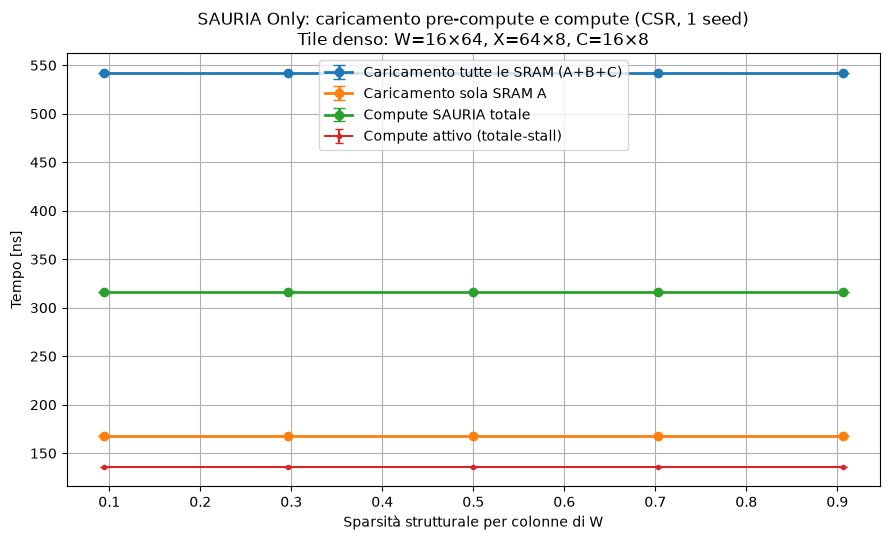

/home/henry/sauria/test/spmm_gather_vs_dense_int8/requested_phases_sauria_only_csr_64_column_structured_multiseed.png


In [10]:
if not summary.empty:
    figure = plt.figure(figsize=(9, 5.5))
    x = summary["sparsity"]

    plt.errorbar(
        x,
        summary["dense_all_sram_load_ns_mean"],
        yerr=summary["dense_all_sram_load_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Caricamento tutte le SRAM (A+B+C)",
    )
    plt.errorbar(
        x,
        summary["dense_sram_a_load_ns_mean"],
        yerr=summary["dense_sram_a_load_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Caricamento sola SRAM A",
    )
    plt.errorbar(
        x,
        summary["dense_compute_ns_mean"],
        yerr=summary["dense_compute_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Compute SAURIA totale",
    )
    plt.errorbar(
        x,
        summary["dense_core_active_ns_mean"],
        yerr=summary["dense_core_active_ns_std"],
        marker=".",
        linewidth=1.5,
        capsize=3,
        label="Compute attivo (totale-stall)",
    )

    plt.xlabel("Sparsità strutturale per colonne di W")
    plt.ylabel("Tempo [ns]")
    plt.title(
        f"SAURIA Only: caricamento pre-compute e compute "
        f"({SPARSE_FORMAT}, {NUM_SEEDS} seed)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"requested_phases_sauria_only_{SPARSE_FORMAT.lower()}_{K}_"
        "column_structured_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


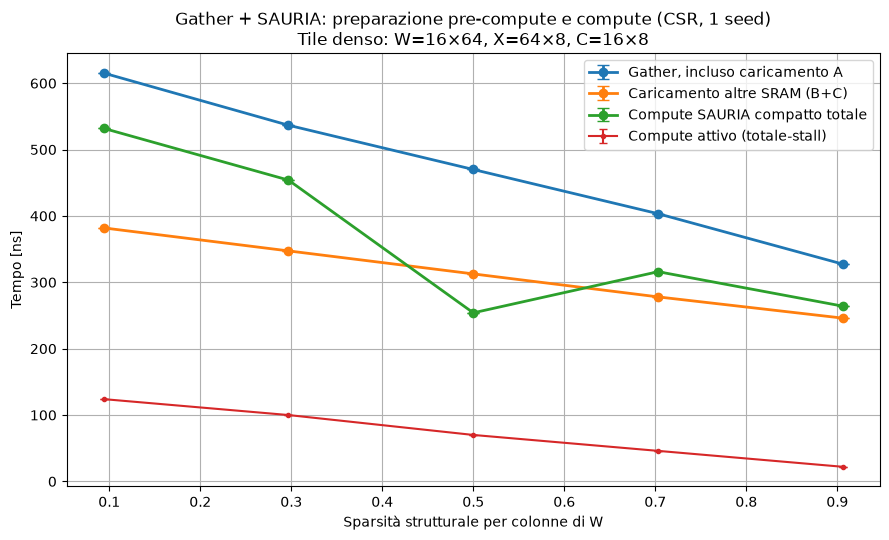

/home/henry/sauria/test/spmm_gather_vs_dense_int8/requested_phases_gather_sauria_csr_64_column_structured_multiseed.png


In [11]:
if not summary.empty:
    figure = plt.figure(figsize=(9, 5.5))
    x = summary["sparsity"]

    plt.errorbar(
        x,
        summary["gather_unit_ns_mean"],
        yerr=summary["gather_unit_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Gather, incluso caricamento A",
    )
    plt.errorbar(
        x,
        summary["gather_other_sram_load_ns_mean"],
        yerr=summary["gather_other_sram_load_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Caricamento altre SRAM (B+C)",
    )
    plt.errorbar(
        x,
        summary["gather_compute_ns_mean"],
        yerr=summary["gather_compute_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Compute SAURIA compatto totale",
    )
    plt.errorbar(
        x,
        summary["gather_core_active_ns_mean"],
        yerr=summary["gather_core_active_ns_std"],
        marker=".",
        linewidth=1.5,
        capsize=3,
        label="Compute attivo (totale-stall)",
    )

    plt.xlabel("Sparsità strutturale per colonne di W")
    plt.ylabel("Tempo [ns]")
    plt.title(
        f"Gather + SAURIA: preparazione pre-compute e compute "
        f"({SPARSE_FORMAT}, {NUM_SEEDS} seed)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"requested_phases_gather_sauria_{SPARSE_FORMAT.lower()}_{K}_"
        "column_structured_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


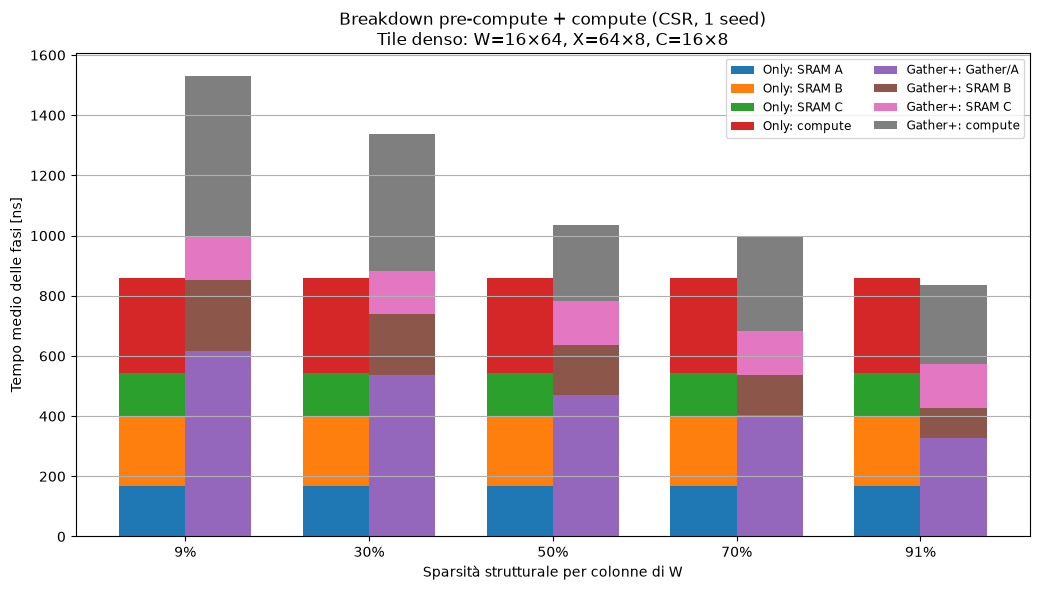

/home/henry/sauria/test/spmm_gather_vs_dense_int8/phase_breakdown_stacked_csr_64_column_structured_multiseed.png


In [12]:
if not summary.empty:
    figure = plt.figure(figsize=(10.5, 6.0))

    x = np.arange(len(summary))
    width = 0.36

    dense_a = summary["dense_sram_a_load_ns_mean"].to_numpy()
    dense_b = summary["dense_sram_b_load_ns_mean"].to_numpy()
    dense_c = summary["dense_sram_c_load_ns_mean"].to_numpy()
    dense_compute = summary["dense_compute_ns_mean"].to_numpy()

    gather_unit = summary["gather_unit_ns_mean"].to_numpy()
    gather_b = summary["gather_sram_b_load_ns_mean"].to_numpy()
    gather_c = summary["gather_sram_c_load_ns_mean"].to_numpy()
    gather_compute = summary["gather_compute_ns_mean"].to_numpy()

    plt.bar(x - width / 2, dense_a, width, label="Only: SRAM A")
    plt.bar(
        x - width / 2,
        dense_b,
        width,
        bottom=dense_a,
        label="Only: SRAM B",
    )
    plt.bar(
        x - width / 2,
        dense_c,
        width,
        bottom=dense_a + dense_b,
        label="Only: SRAM C",
    )
    plt.bar(
        x - width / 2,
        dense_compute,
        width,
        bottom=dense_a + dense_b + dense_c,
        label="Only: compute",
    )

    plt.bar(x + width / 2, gather_unit, width, label="Gather+: Gather/A")
    plt.bar(
        x + width / 2,
        gather_b,
        width,
        bottom=gather_unit,
        label="Gather+: SRAM B",
    )
    plt.bar(
        x + width / 2,
        gather_c,
        width,
        bottom=gather_unit + gather_b,
        label="Gather+: SRAM C",
    )
    plt.bar(
        x + width / 2,
        gather_compute,
        width,
        bottom=gather_unit + gather_b + gather_c,
        label="Gather+: compute",
    )

    labels = [
        f"{value:.0%}"
        for value in summary["sparsity"]
    ]
    plt.xticks(x, labels)
    plt.xlabel("Sparsità strutturale per colonne di W")
    plt.ylabel("Tempo medio delle fasi [ns]")
    plt.title(
        f"Breakdown pre-compute + compute "
        f"({SPARSE_FORMAT}, {NUM_SEEDS} seed)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True, axis="y")
    plt.legend(fontsize="small", ncol=2)
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"phase_breakdown_stacked_{SPARSE_FORMAT.lower()}_{K}_"
        "column_structured_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


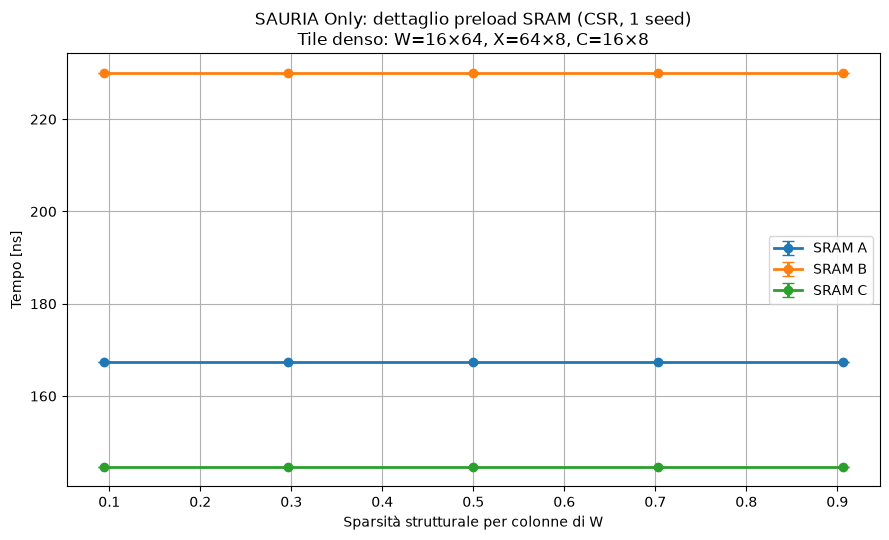

/home/henry/sauria/test/spmm_gather_vs_dense_int8/sram_detail_sauria_only_csr_64_column_structured_multiseed.png


In [13]:
if not summary.empty:
    figure = plt.figure(figsize=(9, 5.5))
    x = summary["sparsity"]

    for key, label in [
        ("dense_sram_a_load_ns", "SRAM A"),
        ("dense_sram_b_load_ns", "SRAM B"),
        ("dense_sram_c_load_ns", "SRAM C"),
    ]:
        plt.errorbar(
            x,
            summary[f"{key}_mean"],
            yerr=summary[f"{key}_std"],
            marker="o",
            linewidth=2,
            capsize=4,
            label=label,
        )

    plt.xlabel("Sparsità strutturale per colonne di W")
    plt.ylabel("Tempo [ns]")
    plt.title(
        f"SAURIA Only: dettaglio preload SRAM "
        f"({SPARSE_FORMAT}, {NUM_SEEDS} seed)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"sram_detail_sauria_only_{SPARSE_FORMAT.lower()}_{K}_"
        "column_structured_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


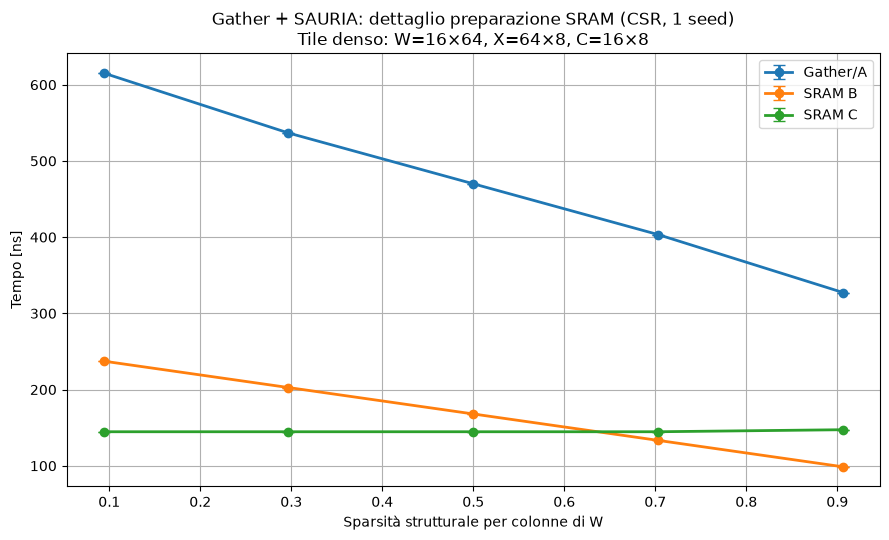

/home/henry/sauria/test/spmm_gather_vs_dense_int8/sram_detail_gather_sauria_csr_64_column_structured_multiseed.png


In [14]:
if not summary.empty:
    figure = plt.figure(figsize=(9, 5.5))
    x = summary["sparsity"]

    plt.errorbar(
        x,
        summary["gather_unit_ns_mean"],
        yerr=summary["gather_unit_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Gather/A",
    )
    plt.errorbar(
        x,
        summary["gather_sram_b_load_ns_mean"],
        yerr=summary["gather_sram_b_load_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="SRAM B",
    )
    plt.errorbar(
        x,
        summary["gather_sram_c_load_ns_mean"],
        yerr=summary["gather_sram_c_load_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="SRAM C",
    )

    plt.xlabel("Sparsità strutturale per colonne di W")
    plt.ylabel("Tempo [ns]")
    plt.title(
        f"Gather + SAURIA: dettaglio preparazione SRAM "
        f"({SPARSE_FORMAT}, {NUM_SEEDS} seed)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"sram_detail_gather_sauria_{SPARSE_FORMAT.lower()}_{K}_"
        "column_structured_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


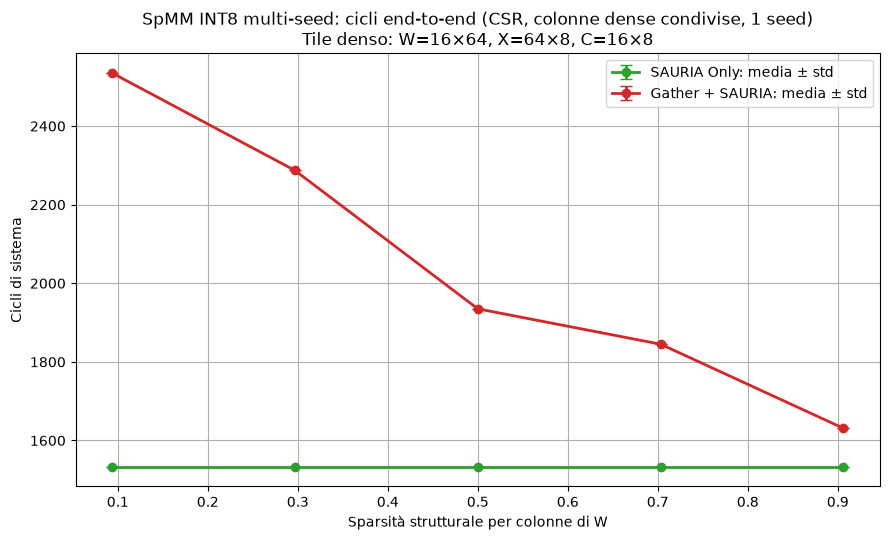

/home/henry/sauria/test/spmm_gather_vs_dense_int8/cycles_vs_column_sparsity_csr_64_column_structured_multiseed.png


In [15]:
if not results.empty:
    figure = plt.figure(figsize=(9, 5.5))

    for _, seed_data in results.groupby("seed_index"):
        seed_data = seed_data.sort_values("sparsity")
        plt.plot(
            seed_data["sparsity"],
            seed_data["dense_cycles"],
            marker=".",
            alpha=0.25,
        )
        plt.plot(
            seed_data["sparsity"],
            seed_data["gather_plus_sauria_cycles"],
            marker=".",
            alpha=0.25,
        )

    plt.errorbar(
        summary["sparsity"],
        summary["dense_cycles_mean"],
        yerr=summary["dense_cycles_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="SAURIA Only: media ± std",
    )
    plt.errorbar(
        summary["sparsity"],
        summary["gather_cycles_mean"],
        yerr=summary["gather_cycles_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Gather + SAURIA: media ± std",
    )

    plt.xlabel("Sparsità strutturale per colonne di W")
    plt.ylabel("Cicli di sistema")
    plt.title(
        f"SpMM INT8 multi-seed: cicli end-to-end "
        f"({SPARSE_FORMAT}, colonne dense condivise, {NUM_SEEDS} seed)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"cycles_vs_column_sparsity_{SPARSE_FORMAT.lower()}_{K}_"
        "column_structured_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


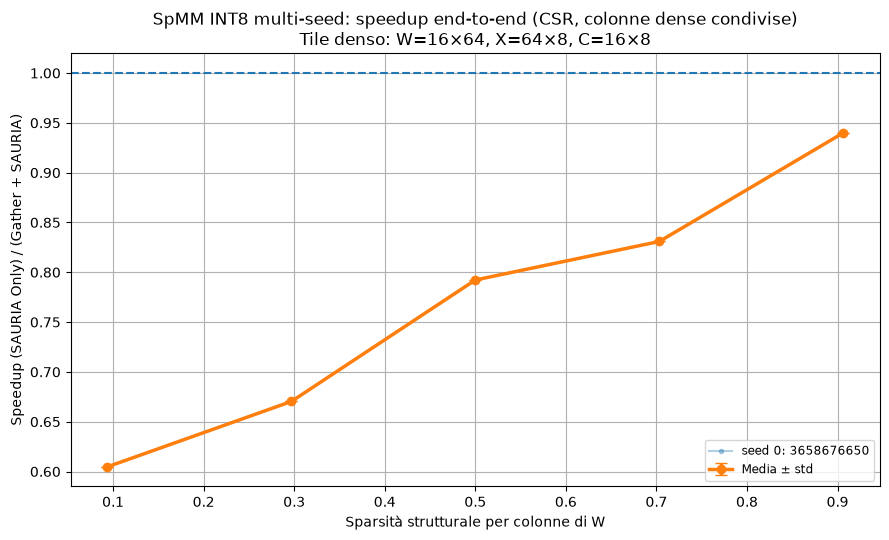

/home/henry/sauria/test/spmm_gather_vs_dense_int8/speedup_vs_column_sparsity_csr_64_column_structured_multiseed.png


In [16]:
if not results.empty:
    figure = plt.figure(figsize=(9, 5.5))

    for seed_index, seed_data in results.groupby("seed_index"):
        seed_data = seed_data.sort_values("sparsity")
        seed_value = int(seed_data["seed"].iloc[0])
        plt.plot(
            seed_data["sparsity"],
            seed_data["speedup_end_to_end"],
            marker=".",
            alpha=0.35,
            label=f"seed {seed_index}: {seed_value}",
        )

    plt.errorbar(
        summary["sparsity"],
        summary["speedup_mean"],
        yerr=summary["speedup_std"],
        marker="o",
        linewidth=2.5,
        capsize=4,
        label="Media ± std",
    )
    plt.axhline(1.0, linestyle="--")
    plt.xlabel("Sparsità strutturale per colonne di W")
    plt.ylabel("Speedup (SAURIA Only) / (Gather + SAURIA)")
    plt.title(
        f"SpMM INT8 multi-seed: speedup end-to-end "
        f"({SPARSE_FORMAT}, colonne dense condivise)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend(fontsize="small")
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"speedup_vs_column_sparsity_{SPARSE_FORMAT.lower()}_{K}_"
        "column_structured_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


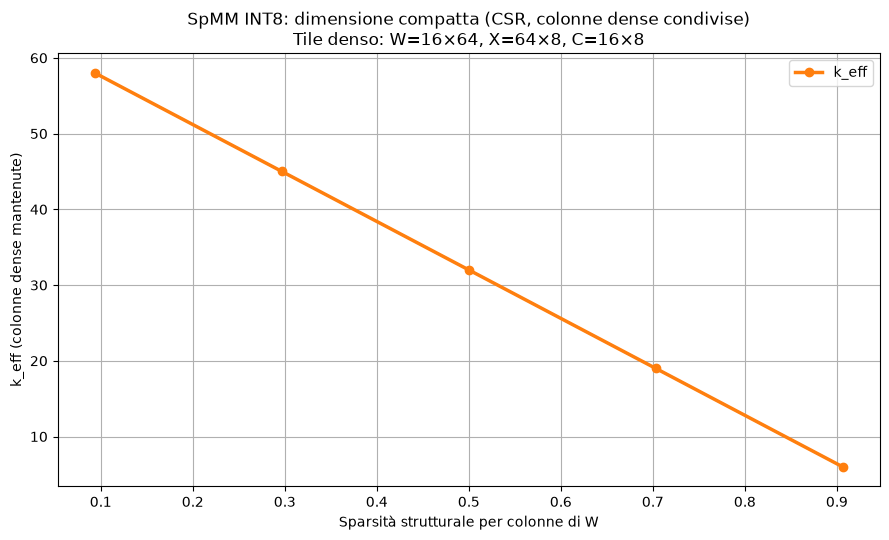

/home/henry/sauria/test/spmm_gather_vs_dense_int8/keff_vs_column_sparsity_csr_64_column_structured_multiseed.png


In [17]:
if not results.empty:
    figure = plt.figure(figsize=(9, 5.5))

    for _, seed_data in results.groupby("seed_index"):
        seed_data = seed_data.sort_values("sparsity")
        plt.plot(
            seed_data["sparsity"],
            seed_data["k_eff"],
            marker=".",
            alpha=0.35,
        )

    plt.plot(
        summary["sparsity"],
        summary["k_eff"],
        marker="o",
        linewidth=2.5,
        label="k_eff",
    )
    plt.xlabel("Sparsità strutturale per colonne di W")
    plt.ylabel("k_eff (colonne dense mantenute)")
    plt.title(
        f"SpMM INT8: dimensione compatta "
        f"({SPARSE_FORMAT}, colonne dense condivise)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"keff_vs_column_sparsity_{SPARSE_FORMAT.lower()}_{K}_"
        "column_structured_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)

In [18]:
if not results.empty:
    selected = (
        results
        .sort_values(["sparsity", "seed_index"])
        .iloc[-1]
    )
    case_root = Path(selected["case_root"])
    print("Seed selezionato:", int(selected["seed"]))
    arrays = np.load(case_root / "operands_and_sparse_formats.npz")

    print("Caso:", case_root)
    print("Shape W_dense:", arrays["W_dense"].shape)
    print("Shape W_compact:", arrays["W_compact"].shape)
    print("Shape X_full:", arrays["X_full"].shape)
    print("Shape X_compact:", arrays["X_compact"].shape)
    print("active_columns:", arrays["active_columns"])
    print("Zeri in W_compact:", int(np.count_nonzero(arrays["W_compact"] == 0)))
    print("Zeri in X_compact:", int(np.count_nonzero(arrays["X_compact"] == 0)))
    print("CSR row_ptr:", arrays["csr_row_ptr"])
    print("CSR col_idx, primi 32:", arrays["csr_col_idx"][:32])
    print("CSC col_ptr:", arrays["csc_col_ptr"])
    print("CSC row_idx, primi 32:", arrays["csc_row_idx"][:32])

    print("\nManifest sparse:")
    print((case_root / "sparse_case_manifest.json").read_text())
    print("\nManifest Gather:")
    print((case_root / "gather_stimuli/manifest.json").read_text())

Seed selezionato: 3658676650
Caso: /home/henry/sauria/test/spmm_gather_vs_dense_int8/seed_00_3658676650/csr_K064_keff006_scol0.9062
Shape W_dense: (16, 64)
Shape W_compact: (16, 6)
Shape X_full: (64, 8)
Shape X_compact: (6, 8)
active_columns: [24 25 29 43 55 59]
Zeri in W_compact: 0
Zeri in X_compact: 0
CSR row_ptr: [ 0  6 12 18 24 30 36 42 48 54 60 66 72 78 84 90 96]
CSR col_idx, primi 32: [24 25 29 43 55 59 24 25 29 43 55 59 24 25 29 43 55 59 24 25 29 43 55 59
 24 25 29 43 55 59 24 25]
CSC col_ptr: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0 16 32 32 32 32 48 48 48 48 48 48 48 48 48 48 48 48 48 48 64 64 64 64
 64 64 64 64 64 64 64 64 80 80 80 80 96 96 96 96 96]
CSC row_idx, primi 32: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15  0  1  2  3  4  5  6  7
  8  9 10 11 12 13 14 15]

Manifest sparse:
{
  "seed": 3658676650,
  "master_seed": 2026,
  "M": 16,
  "K": 64,
  "N": 8,
  "k_eff": 6,
  "column_sparsity": 0.90625,
  "element_sparsity": 0.90625,
 

## Modifica RTL richiesta

Per ottenere misure esatte dei trasferimenti pre-compute è necessario aggiungere
il modulo simulativo `sauria_phase_monitor.sv`.

Il modulo:

- osserva il primo handshake AXI AW del DMA verso le regioni SRAM A, B e C;
- associa il successivo interrupt del writer DMA alla fine del trasferimento;
- misura il Gather dal fronte di salita di `gather_busy` a `gather_doneintr`;
- osserva `sauria_intr2control` e ignora nuovi trasferimenti dopo il completamento
  del core, evitando di contare il writeback finale di C;
- è racchiuso in `` `ifndef SYNTHESIS `` e non modifica il datapath sintetizzato.

Marker prodotti:

```text
[PERF_PHASE] phase=SRAM_A_LOAD event=START cycle=...
[PERF_PHASE] phase=SRAM_A_LOAD event=DONE  cycle=...
[PERF_PHASE] phase=SRAM_B_LOAD event=START cycle=...
[PERF_PHASE] phase=SRAM_B_LOAD event=DONE  cycle=...
[PERF_PHASE] phase=SRAM_C_LOAD event=START cycle=...
[PERF_PHASE] phase=SRAM_C_LOAD event=DONE  cycle=...
[PERF_PHASE] phase=GATHER event=START cycle=...
[PERF_PHASE] phase=GATHER event=DONE  cycle=...
```

Copiare il modulo in `RTL/src`, aggiungerlo a `RTL/filelist.f` e istanziarlo nel
subsystem seguendo il file `SAURIA_PHASE_MONITOR_INTEGRATION.md`.


## Interpretazione

La somma delle durate A+B+C o B+C rappresenta il tempo occupato dai trasferimenti
DMA veri e propri. Non include gli intervalli di configurazione del controller tra
un trasferimento e il successivo; tali overhead restano inclusi nel tempo
end-to-end.

`compute totale` è il contatore del core letto a `0x50000014`.
`compute attivo` è calcolato come `compute totale - stall`, usando il contatore
`0x50000018`.

Il CSV completo conserva ogni run e ogni fase. Il CSV aggregato riporta media e
deviazione standard per livello di sparsità.
